<a href="https://colab.research.google.com/github/Onyimatics/Stellar-Classification-With-Machine-Learning/blob/master/StellarClassificationML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade xgboost
!pip install hdbscan
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.1 MB/s eta 0:00:00


In [ ]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, LabelEncoder
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, RFE, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from xgboost import XGBClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.mixture import GaussianMixture
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import IsolationForest, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, silhouette_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from yellowbrick.classifier import ConfusionMatrix
from yellowbrick.classifier import ClassPredictionError
from yellowbrick.classifier import ROCAUC
from yellowbrick.style import set_palette
from sklearn.manifold import TSNE
from itertools import cycle
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.6.0
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License
         
         Copyright (c) 2007-2024 The scikit-learn developers.
         All rights reserved.
         
         Redistribution and use in source and binary forms, with or without
         modification, are permitted provided that the following conditions are met:
         
         * Redistributions of source code must retain the above copyright notice, this
           list of conditions and the following disclaimer.
         
         * Redistributions in binary form must reproduce the above copyright notice,
           this list of conditions and the following disclaimer in the documentation
           and/or other materials provided with the distribution.
         
         * Neither the name of the copyright holder nor the names of its
           contributors may be used to endorse 

In [ ]:
!pip uninstall -y scikit-learn

Found existing installation: scikit-learn 1.6.0
Uninstalling scikit-learn-1.6.0:
  Successfully uninstalled scikit-learn-1.6.0


In [ ]:
!pip install scikit-learn==1.3.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 21.9 MB/s eta 0:00:00


##1. First, let's load and examine the data:

In [ ]:
# Load the data
# stellar_df = pd.read_csv('stellar_classification.csv')
stellar_df = pd.read_csv('https://raw.githubusercontent.com/Onyimatics/Stellar-Classification-With-Machine-Learning/refs/heads/master/stellar_classification.csv')

In [ ]:
# check data info
stellar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   obj_ID       10000 non-null  float64
 1   alpha        10000 non-null  float64
 2   delta        10000 non-null  float64
 3   u            10000 non-null  float64
 4   g            10000 non-null  float64
 5   r            10000 non-null  float64
 6   i            10000 non-null  float64
 7   z            10000 non-null  float64
 8   run_ID       10000 non-null  int64  
 9   rerun_ID     10000 non-null  int64  
 10  cam_col      10000 non-null  int64  
 11  field_ID     10000 non-null  int64  
 12  spec_obj_ID  10000 non-null  float64
 13  class        10000 non-null  object 
 14  redshift     10000 non-null  float64
 15  plate        10000 non-null  int64  
 16  MJD          10000 non-null  int64  
 17  fiber_ID     10000 non-null  int64  
dtypes: float64(10), int64(7), object(1)
memory usag

In [ ]:
rows,columns = stellar_df.shape
print(f"Number of rows/examples: {rows}")
print(f"Number of columns/features: {columns}")

Number of rows/examples: 10000
Number of columns/features: 18


In [ ]:
stellar_df.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')

In [ ]:
stellar_df.describe().T

,count,mean,std,min,25%,50%,75%,max
obj_ID,10000.0,1.237665e+18,8.432263e+12,1.237646e+18,1.237659e+18,1.237663e+18,1.237668e+18,1.237681e+18
alpha,10000.0,1.764133e+02,9.675617e+01,4.480456e-02,1.267633e+02,1.804910e+02,2.323913e+02,3.599936e+02
delta,10000.0,2.407284e+01,1.966758e+01,-1.757382e+01,5.254813e+00,2.345650e+01,3.991129e+01,8.300052e+01
u,10000.0,2.205780e+01,2.241957e+00,1.394716e+01,2.032369e+01,2.217896e+01,2.368715e+01,2.932565e+01
g,10000.0,2.061277e+01,2.039581e+00,1.174518e+01,1.894655e+01,2.106067e+01,2.213245e+01,2.741465e+01
r,10000.0,1.962870e+01,1.862932e+00,1.086379e+01,1.807662e+01,2.008670e+01,2.103985e+01,2.957186e+01
i,10000.0,1.906571e+01,1.760867e+00,1.056647e+01,1.769002e+01,1.937056e+01,2.036731e+01,3.214147e+01
z,10000.0,1.875488e+01,1.778200e+00,1.077889e+01,1.742536e+01,1.897302e+01,1.988999e+01,2.879055e+01
run_ID,10000.0,4.481872e+03,1.963299e+03,1.090000e+02,3.184750e+03,4.188000e+03,5.330000e+03,8.162000e+03
rerun_ID,10000.0,3.010000e+02,0.000000e+00,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02


In [ ]:
# check for null values
stellar_df.isnull().sum()

,0
obj_ID,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
run_ID,0
rerun_ID,0


No Null Values on the Dataset

In [ ]:
# check for duploicates
stellar_df.duplicated().sum()

0

No duplicates

In [ ]:
stellar_df['class'].value_counts()

,count
class,
GALAXY,5945
STAR,2159
QSO,1896


The Dataset looks imbalanced!

In [ ]:
stellar_df.shape

(10000, 18)

##2. EXPLORATORY DATA ANALYSIS:

Basic Statistics of dataset:

Mean, variance or standard deviation (descriptive)

In [ ]:
stellar_df_without_class = stellar_df.loc[:,stellar_df.columns!='class']

stellar_df_without_class

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
0,1.237650e+18,48.824760,-8.166999,19.44393,18.43291,18.11620,17.98857,17.95942,1045,301,1,98,3.587172e+18,-0.000996,3186,54853,201
1,1.237658e+18,193.394684,52.336221,22.41654,22.09867,20.53718,19.63900,19.28375,2830,301,4,454,7.513333e+18,0.518672,6673,56419,739
2,1.237679e+18,324.020999,10.000606,19.49719,17.58264,16.66178,16.18781,15.85648,7777,301,5,87,4.608454e+18,0.077720,4093,55475,530
3,1.237666e+18,234.965903,23.031949,24.31149,21.99310,20.58364,19.76995,19.39575,4671,301,5,41,4.445071e+18,0.471659,3948,55331,66
4,1.237665e+18,170.706066,35.630196,25.61850,24.86680,21.37659,19.77067,19.26844,4504,301,1,94,5.199500e+18,0.720088,4618,55600,343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.237658e+18,181.269532,51.273043,18.50853,17.65012,17.27569,16.85724,16.74033,2830,301,1,404,9.930663e+17,0.086213,882,52370,82
9996,1.237668e+18,209.743620,19.894152,22.99436,22.08630,20.23164,19.36716,18.90923,5194,301,2,618,6.607022e+18,0.444164,5868,56045,879
9997,1.237662e+18,177.389727,6.270422,19.52580,17.92479,17.11512,16.69188,16.42343,3841,301,1,84,1.825122e+18,0.072649,1621,53383,139
9998,1.237668e+18,217.297701,15.970520,21.95136,20.81498,19.93374,19.41501,19.25114,5326,301,6,113,6.154330e+18,1.783821,5466,56033,584


In [ ]:
mean = stellar_df_without_class.mean() # mean of the dataset

In [ ]:
var = stellar_df_without_class.var() # variance of the dataset

In [ ]:
mean

,0
obj_ID,1.237665e+18
alpha,1.764133e+02
delta,2.407284e+01
u,2.205780e+01
g,2.061277e+01
r,1.962870e+01
i,1.906571e+01
z,1.875488e+01
run_ID,4.481872e+03
rerun_ID,3.010000e+02


In [ ]:
var

,0
obj_ID,7.110307e+25
alpha,9.361757e+03
delta,3.868138e+02
u,5.026369e+00
g,4.159891e+00
r,3.470515e+00
i,3.100651e+00
z,3.161996e+00
run_ID,3.854543e+06
rerun_ID,0.000000e+00


In [ ]:
# Checking for NaN data (Not a Number)

nan_data_by_column = stellar_df.isna().sum()

nan_total_data = stellar_df.isna().sum().sum()



print("NaN data by column:")

print(nan_data_by_column)

print("\nTotal NaN data in DataFrame:", nan_total_data)


NaN data by column:
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

Total NaN data in DataFrame: 0


In [ ]:
class_gal_df = stellar_df[stellar_df['class'] == 'GALAXY']

class_star_df = stellar_df[stellar_df['class'] == 'STAR']

class_qso_df = stellar_df[stellar_df['class'] == 'QSO']



# Calculate the mean

mean_gal = class_gal_df.select_dtypes(include=np.number).mean()

mean_star = class_star_df.select_dtypes(include=np.number).mean()

mean_qso = class_qso_df.select_dtypes(include=np.number).mean()

print("Mean of Class GALAXY:\n", mean_gal)

print("Mean of Class STAR:\n", mean_star)

print("Mean of Class QSO:\n", mean_qso)

Mean of Class GALAXY:
 obj_ID         1.237665e+18
alpha          1.789279e+02
delta          2.347075e+01
u              2.256448e+01
g              2.088559e+01
r              1.956758e+01
i              1.882879e+01
z              1.843013e+01
run_ID         4.515282e+03
rerun_ID       3.010000e+02
cam_col        3.481413e+00
field_ID       1.877802e+02
spec_obj_ID    5.469889e+18
redshift       4.165389e-01
plate          4.858128e+03
MJD            5.542184e+04
fiber_ID       4.483616e+02
dtype: float64
Mean of Class STAR:
 obj_ID         1.237664e+18
alpha          1.675318e+02
delta          2.338044e+01
u              2.110836e+01
g              1.959054e+01
r              1.891842e+01
i              1.849653e+01
z              1.828980e+01
run_ID         4.251386e+03
rerun_ID       3.010000e+02
cam_col        3.616952e+00
field_ID       1.774484e+02
spec_obj_ID    4.784189e+18
redshift      -1.086356e-04
plate          4.249112e+03
MJD            5.512517e+04
fiber_ID       4.

###Class Distribution (Stars, Galaxies and Quasars):

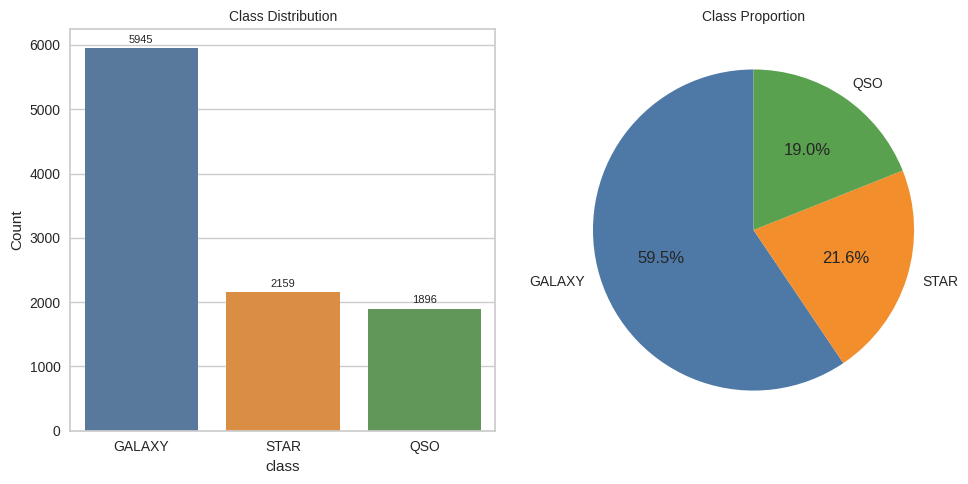

In [ ]:
# Define custom color palette for consistency
palette = ['#4e79a7', '#f28e2b', '#59a14f']  # Blue, Orange, Green

# Create a DataFrame to hold class counts and percentages
class_df = stellar_df['class'].value_counts().to_frame(name='Count')
class_df['Percentage'] = (class_df['Count'] / stellar_df.shape[0] * 100).round(2)

# Create a figure with two subplots
plt.figure(figsize=(10, 5))

# ---- Left Plot: Bar Plot for Class Distribution ----
plt.subplot(121)
bars = sns.barplot(x=class_df.index, y='Count', data=class_df, palette=palette)
for b in bars.patches:
    x = b.get_x() + (b.get_width() / 2)
    y = b.get_height()
    bars.annotate(f'{int(y)}', xy=(x, y), ha='center', va='center', size=8, xytext=(0, 6), textcoords='offset points')
plt.title('Class Distribution', fontsize=10)

# ---- Right Plot: Pie Chart for Class Proportion ----
plt.subplot(122)
plt.pie(class_df['Percentage'], labels=class_df.index, autopct='%1.1f%%', colors=palette, startangle=90)
plt.title('Class Proportion', fontsize=10)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


From the above distribution and proportion plots, we see that the dataset is not balanced across the target variable.

In [ ]:
num_cols = stellar_df.select_dtypes(include=['number']).columns

cat_cols = stellar_df.select_dtypes(include=['object']).columns

##Univariate Analysis

##Statistical Summary of Numerical Features

In [ ]:
# Select only numerical columns (excluding object IDs and categorical variables)
numerical_features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

# Create a comprehensive statistical summary
def get_statistical_summary(stellar_df, features):
    stats_dict = {}

    for feature in features:
        feature_stats = {
            # Central Tendency
            'Mean': stellar_df[feature].mean(),
            'Median': stellar_df[feature].median(),
            'Mode': stellar_df[feature].mode().iloc[0],

            # Dispersion
            'Std Dev': stellar_df[feature].std(),
            'Range': stellar_df[feature].max() - stellar_df[feature].min(),
            'IQR': stellar_df[feature].quantile(0.75) - stellar_df[feature].quantile(0.25),
            'Variance': stellar_df[feature].var(),

            # Distribution Characteristics
            'Skewness': skew(stellar_df[feature].dropna()),
            'Kurtosis': kurtosis(stellar_df[feature].dropna()),

            # Additional Statistics
            'Min': stellar_df[feature].min(),
            'Max': stellar_df[feature].max(),
            '25%': stellar_df[feature].quantile(0.25),
            '75%': stellar_df[feature].quantile(0.75)
        }
        stats_dict[feature] = feature_stats

    # Convert to DataFrame for better visualization
    stats_df = pd.DataFrame(stats_dict)

    return stats_df.round(4)

# Calculate statistics
statistics_summary = get_statistical_summary(stellar_df, numerical_features)

# Display the summary
print("Statistical Summary of Numerical Features:")
print("\nShape of the dataset:", stellar_df.shape)
print("\nDetailed Statistics:")
display(statistics_summary)

# Optionally, create a more visually appealing table using styling
styled_stats = statistics_summary.style.background_gradient(axis=1)\
                                    .format(precision=4)
display(styled_stats)

# Save the statistics to a CSV file if needed
statistics_summary.to_csv('statistical_summary.csv')

Statistical Summary of Numerical Features:

Shape of the dataset: (10000, 18)

Detailed Statistics:


,alpha,delta,u,g,r,i,z,redshift
Mean,176.4133,24.0728,22.0578,20.6128,19.6287,19.0657,18.7549,0.5817
Median,180.4910,23.4565,22.1790,21.0607,20.0867,19.3706,18.9730,0.4122
Mode,0.0448,-17.5738,24.6346,17.0976,16.0129,15.8764,22.8269,0.0000
Std Dev,96.7562,19.6676,2.2420,2.0396,1.8629,1.7609,1.7782,0.7498
Range,359.9488,100.5743,15.3785,15.6695,18.7081,21.5750,18.0117,7.0169
IQR,105.6280,34.6565,3.3635,3.1859,2.9632,2.6773,2.4646,0.6415
Variance,9361.7571,386.8138,5.0264,4.1599,3.4705,3.1007,3.1620,0.5623
Skewness,-0.0275,0.1800,-0.0809,-0.4148,-0.4453,-0.3436,-0.1644,2.6176
Kurtosis,-0.5436,-1.0326,-0.5673,-0.4302,-0.3577,-0.0923,-0.0900,10.6859
Min,0.0448,-17.5738,13.9472,11.7452,10.8638,10.5665,10.7789,-0.0057


,alpha,delta,u,g,r,i,z,redshift
Mean,176.4133,24.0728,22.0578,20.6128,19.6287,19.0657,18.7549,0.5817
Median,180.4910,23.4565,22.1790,21.0607,20.0867,19.3706,18.9730,0.4122
Mode,0.0448,-17.5738,24.6346,17.0976,16.0129,15.8764,22.8269,0.0000
Std Dev,96.7562,19.6676,2.2420,2.0396,1.8629,1.7609,1.7782,0.7498
Range,359.9488,100.5743,15.3785,15.6695,18.7081,21.5750,18.0117,7.0169
IQR,105.6280,34.6565,3.3635,3.1859,2.9632,2.6773,2.4646,0.6415
Variance,9361.7571,386.8138,5.0264,4.1599,3.4705,3.1007,3.1620,0.5623
Skewness,-0.0275,0.1800,-0.0809,-0.4148,-0.4453,-0.3436,-0.1644,2.6176
Kurtosis,-0.5436,-1.0326,-0.5673,-0.4302,-0.3577,-0.0923,-0.0900,10.6859
Min,0.0448,-17.5738,13.9472,11.7452,10.8638,10.5665,10.7789,-0.0057


## Skewness annd Kurtosis Distribution Across Numerical Features

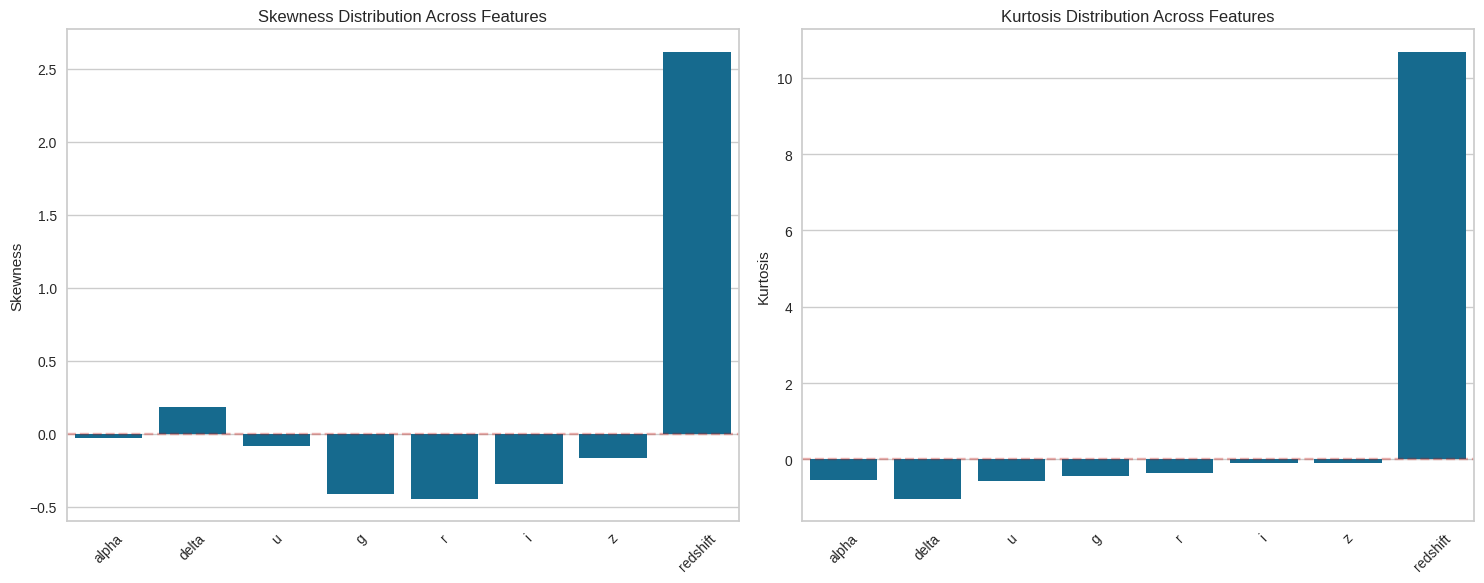

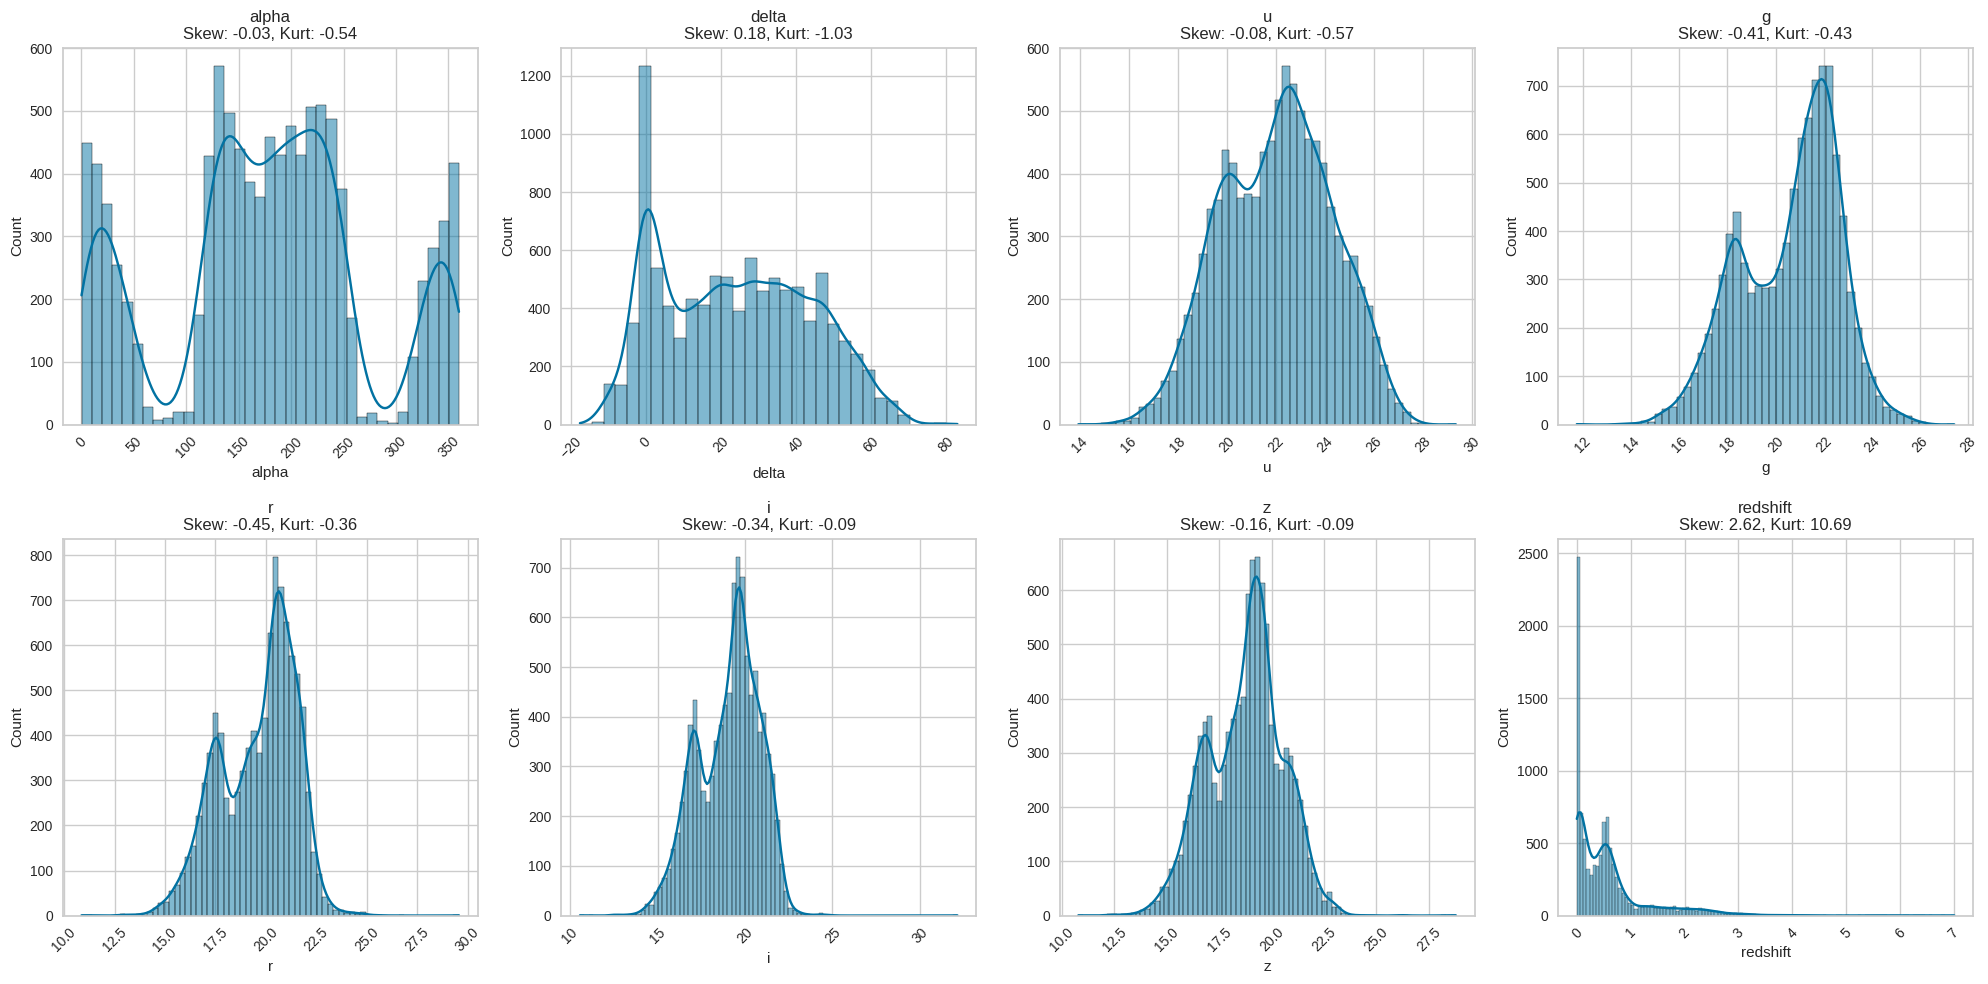


Distribution Characteristics Summary:


,Skewness,Kurtosis
alpha,-0.027547,-0.543617
delta,0.179950,-1.032577
u,-0.080936,-0.567271
g,-0.414801,-0.430189
r,-0.445326,-0.357652
i,-0.343601,-0.092307
z,-0.164357,-0.090018
redshift,2.617603,10.685949


In [ ]:
# Get the numerical features
numerical_features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

# Create a figure with two subplots
plt.figure(figsize=(15, 6))

# Plot Skewness
plt.subplot(1, 2, 1)
skewness_values = [skew(stellar_df[feature].dropna()) for feature in numerical_features]
sns.barplot(x=numerical_features, y=skewness_values)
plt.title('Skewness Distribution Across Features')
plt.xticks(rotation=45)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)  # Add reference line at 0
plt.ylabel('Skewness')

# Plot Kurtosis
plt.subplot(1, 2, 2)
kurtosis_values = [kurtosis(stellar_df[feature].dropna()) for feature in numerical_features]
sns.barplot(x=numerical_features, y=kurtosis_values)
plt.title('Kurtosis Distribution Across Features')
plt.xticks(rotation=45)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)  # Add reference line at 0
plt.ylabel('Kurtosis')

plt.tight_layout()
plt.show()

# For a more detailed visualization including the actual distribution shape
plt.figure(figsize=(20, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 4, i)
    sns.histplot(stellar_df[feature], kde=True)
    plt.title(f'{feature}\nSkew: {skew(stellar_df[feature]):.2f}, Kurt: {kurtosis(stellar_df[feature]):.2f}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Optional: Create a summary DataFrame of the distribution characteristics
distribution_stats = pd.DataFrame({
    'Skewness': skewness_values,
    'Kurtosis': kurtosis_values
}, index=numerical_features)

print("\nDistribution Characteristics Summary:")
display(distribution_stats)

In [ ]:
def plot_distribution(df):
    """
    Plots histograms for all numerical columns in the dataset, 4 in a row.

    Parameters:
    df : DataFrame
        The dataset containing numerical columns.
    """
    # Automatically detect numerical columns
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns

    # Set the number of plots per row
    plots_per_row = 4
    num_plots = len(num_cols)
    num_rows = (num_plots + plots_per_row - 1) // plots_per_row  # Calculate required rows

    # Create subplots
    fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(20, num_rows * 5))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    for idx, col in enumerate(num_cols):
        # Plot each histogram
        ax = axes[idx]
        ax.hist(df[col], bins=30, color='blue', alpha=0.7)
        ax.set_title(f'Histogram of {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')

    # Remove any unused subplots
    for idx in range(num_plots, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

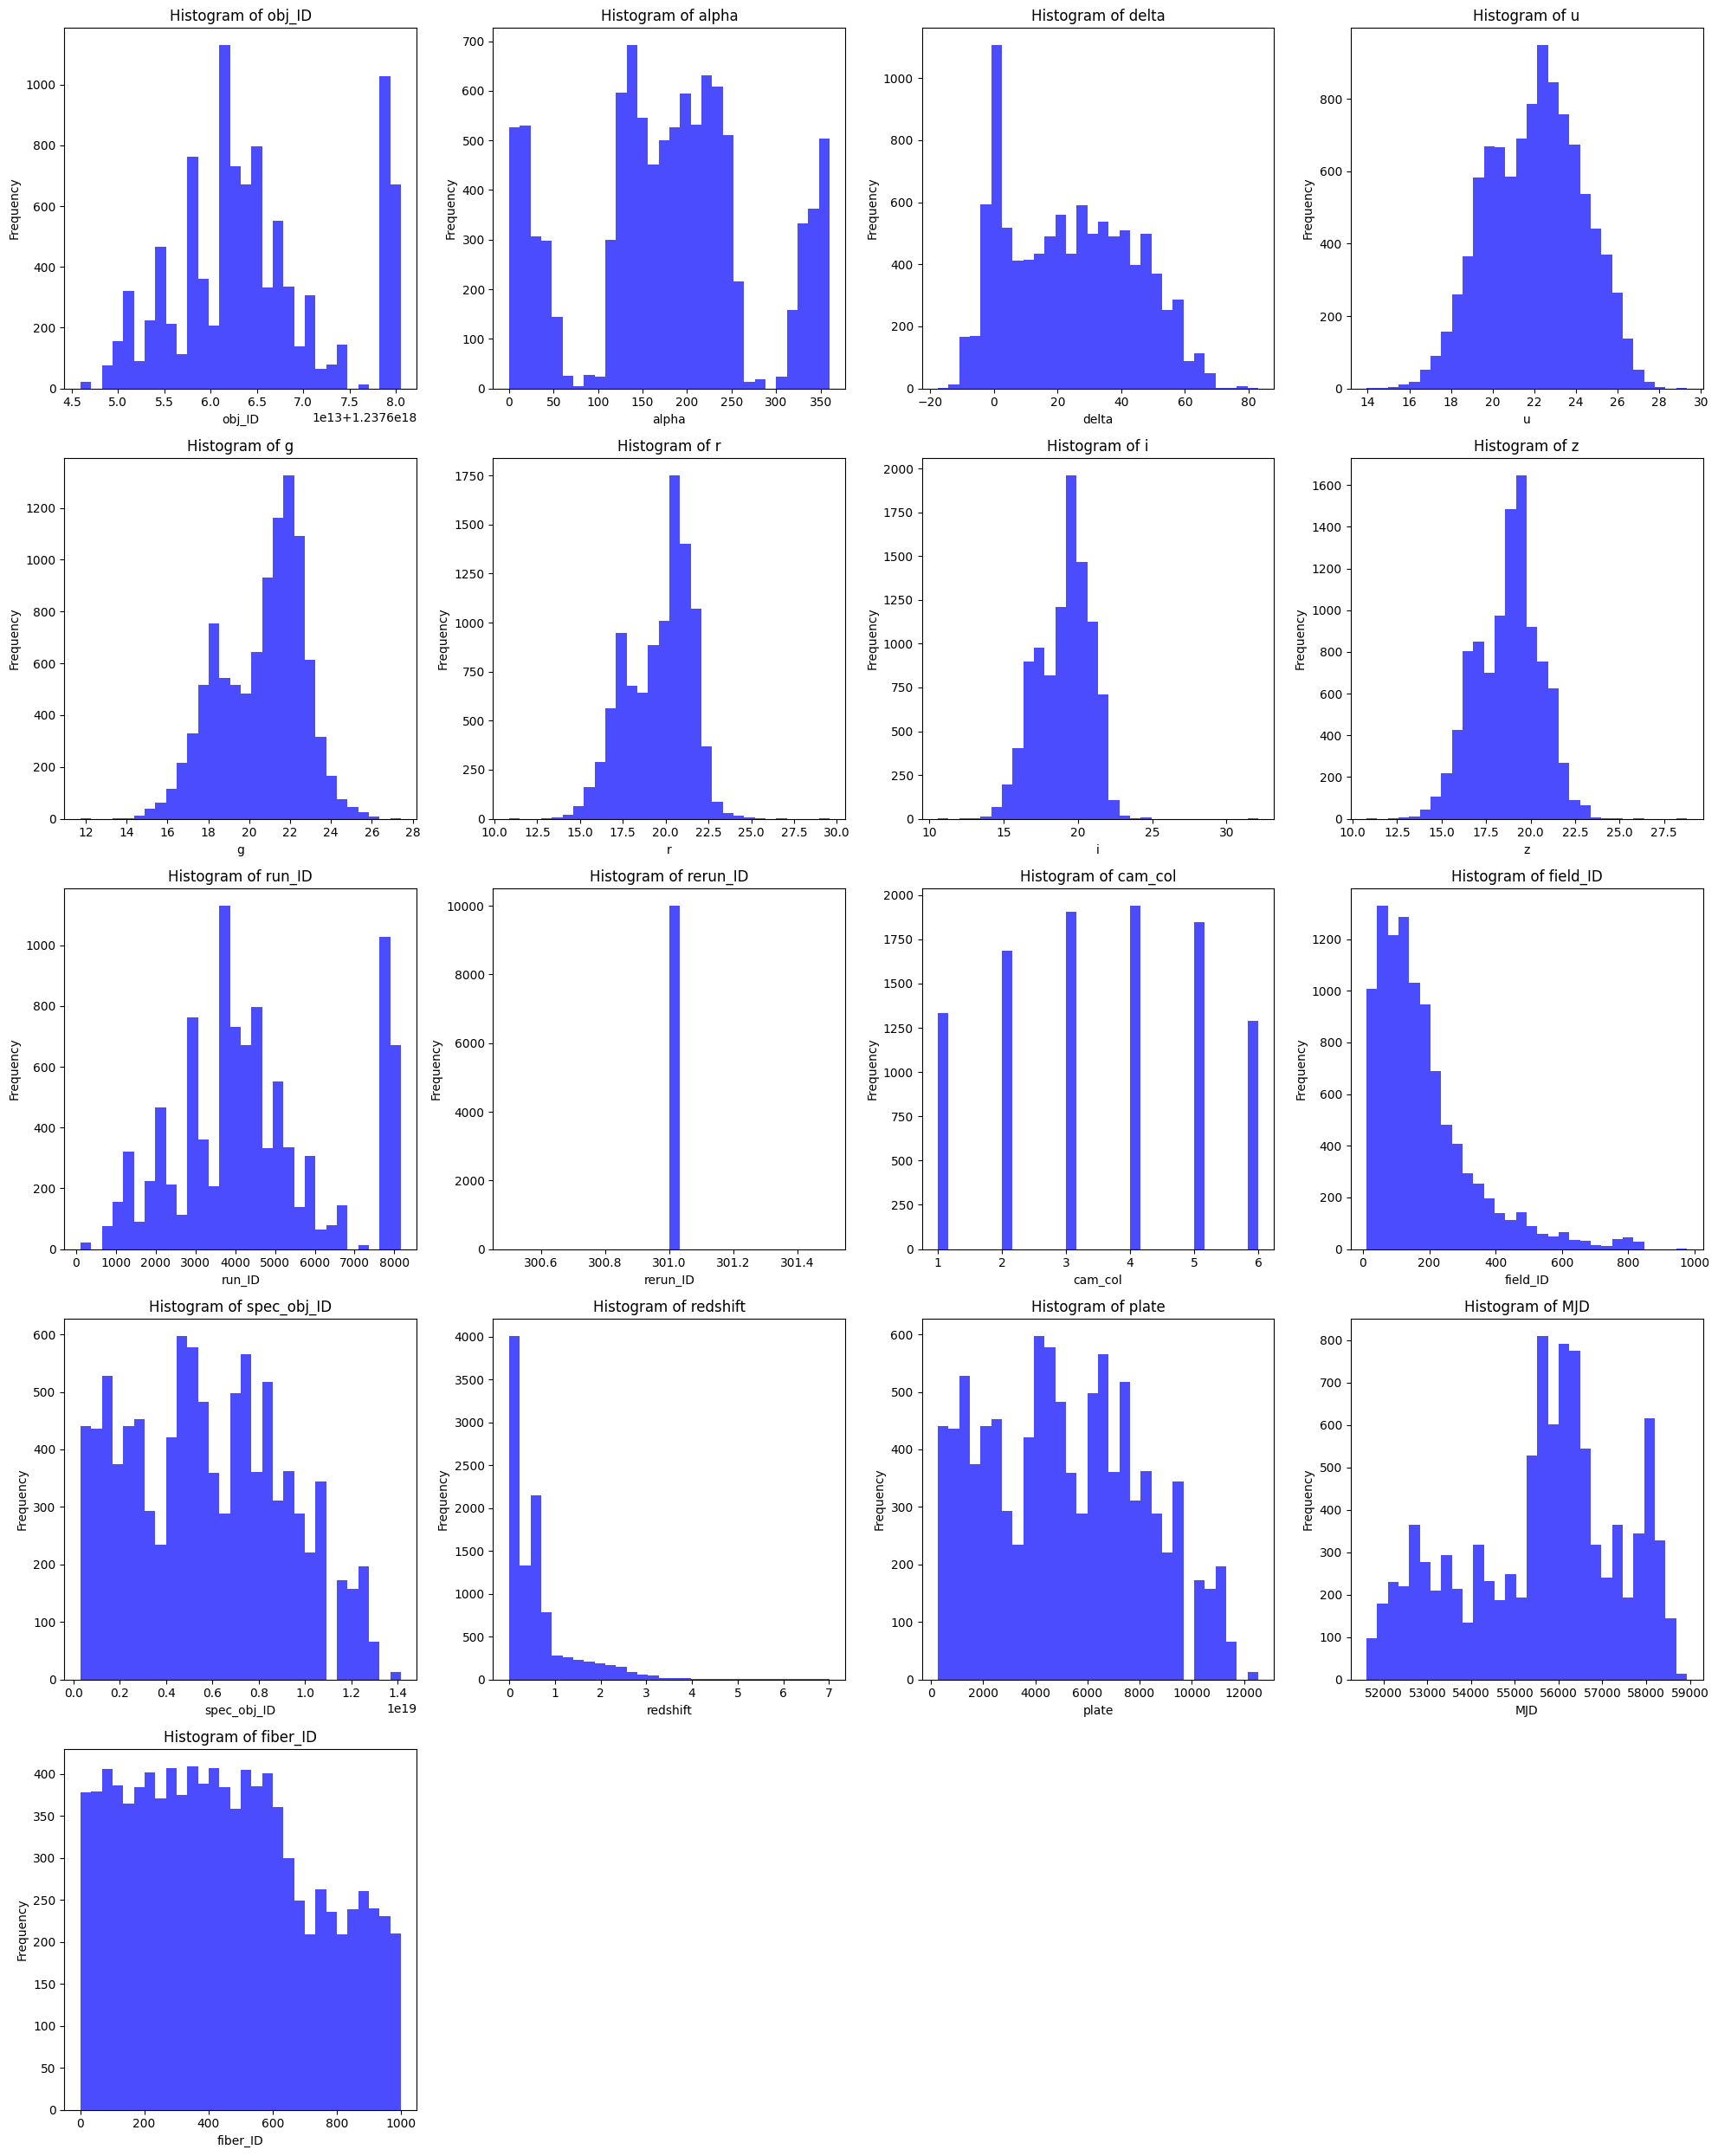

In [ ]:
plot_distribution(stellar_df)

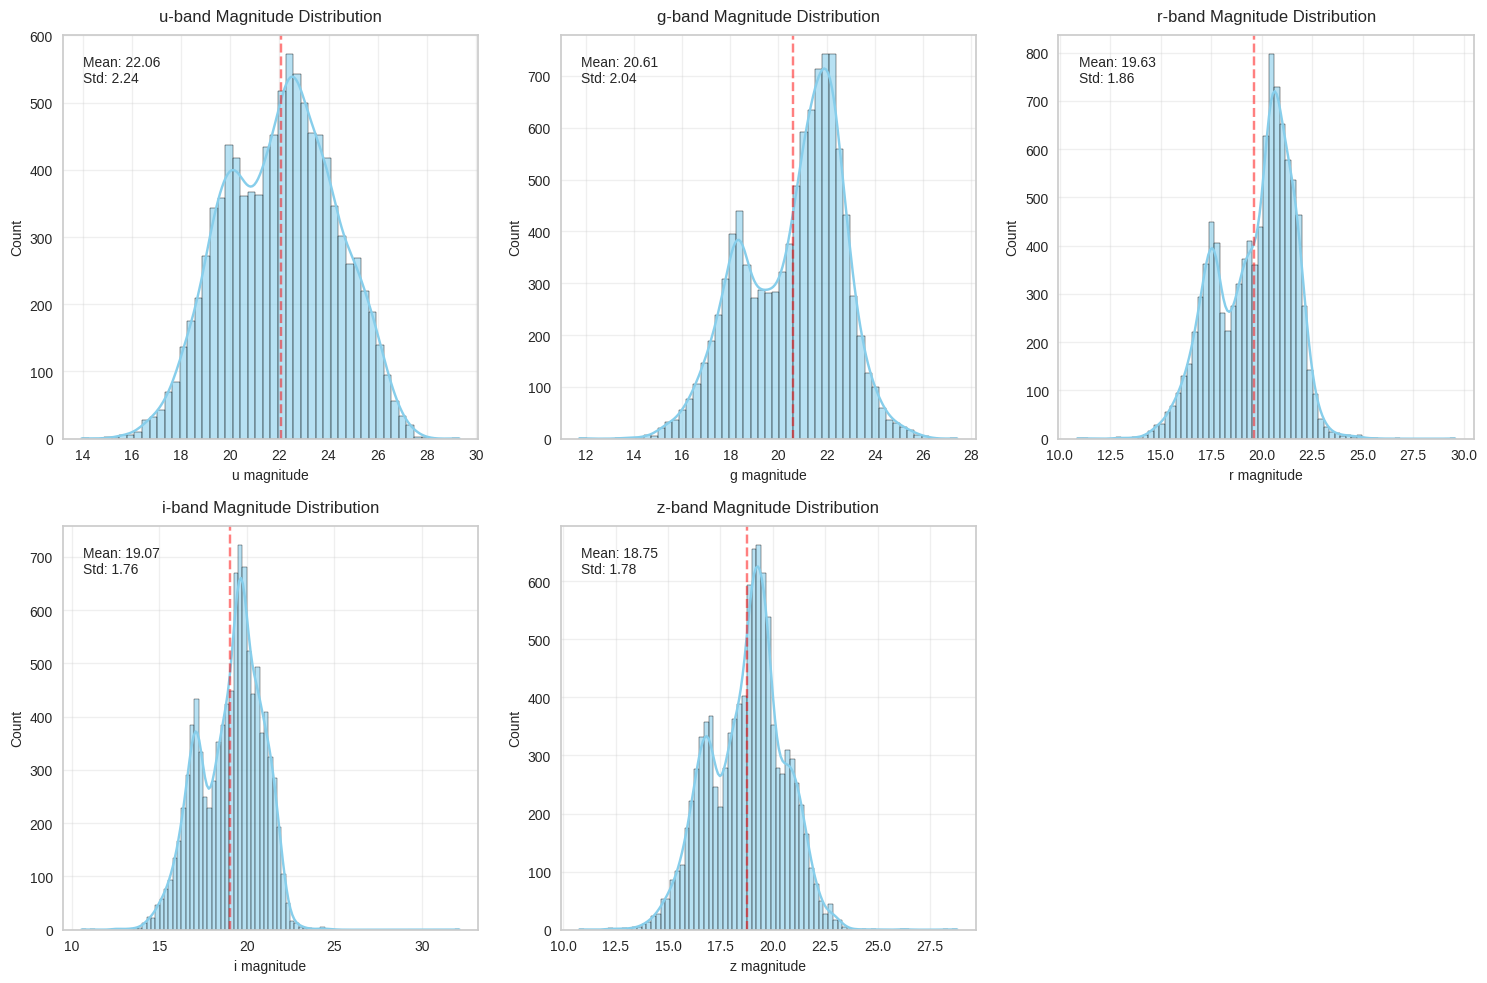


Magnitude Band Statistics:
                  u             g             r             i             z
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000
mean      22.057796     20.612774     19.628704     19.065712     18.754885
std        2.241957      2.039581      1.862932      1.760867      1.778200
min       13.947160     11.745180     10.863790     10.566470     10.778890
25%       20.323692     18.946545     18.076622     17.690020     17.425365
50%       22.178960     21.060670     20.086700     19.370560     18.973020
75%       23.687152     22.132447     21.039848     20.367310     19.889990
max       29.325650     27.414650     29.571860     32.141470     28.790550

u-band metrics:
Skewness: -0.081
Kurtosis: -0.567

g-band metrics:
Skewness: -0.415
Kurtosis: -0.430

r-band metrics:
Skewness: -0.445
Kurtosis: -0.357

i-band metrics:
Skewness: -0.344
Kurtosis: -0.092

z-band metrics:
Skewness: -0.164
Kurtosis: -0.089


In [ ]:
# Create a figure for magnitude distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Photometric bands
mag_bands = ['u', 'g', 'r', 'i', 'z']

# Plot histograms for each magnitude band with improved styling
for idx, band in enumerate(mag_bands):
    # Create histogram with KDE
    sns.histplot(data=stellar_df, x=band, kde=True, ax=axes[idx], color='skyblue', alpha=0.6)

    # Customize the plot
    axes[idx].set_title(f'{band}-band Magnitude Distribution', fontsize=12, pad=10)
    axes[idx].set_xlabel(f'{band} magnitude', fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

    # Add statistics to the plot
    mean_val = stellar_df[band].mean()
    std_val = stellar_df[band].std()
    axes[idx].axvline(mean_val, color='red', linestyle='--', alpha=0.5)
    axes[idx].text(0.05, 0.95, f'Mean: {mean_val:.2f}\nStd: {std_val:.2f}',
                  transform=axes[idx].transAxes, fontsize=10,
                  verticalalignment='top')

# Remove the empty subplot
fig.delaxes(axes[5])

# Adjust layout
plt.tight_layout()
plt.show()

# Print detailed statistics
print("\nMagnitude Band Statistics:")
print(stellar_df[mag_bands].describe())

# Calculate and print distribution metrics
for band in mag_bands:
    skew_val = stellar_df[band].skew()
    kurt_val = stellar_df[band].kurtosis()
    print(f"\n{band}-band metrics:")
    print(f"Skewness: {skew_val:.3f}")
    print(f"Kurtosis: {kurt_val:.3f}")

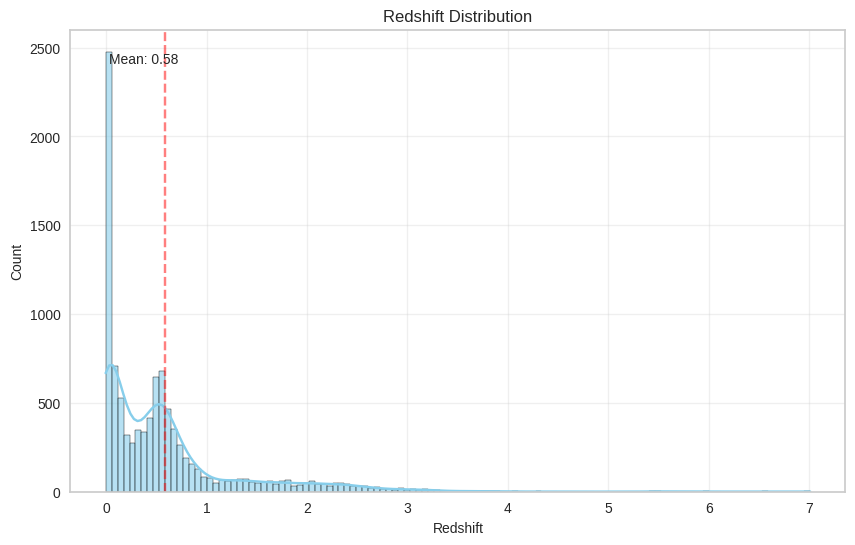


Redshift Statistics:
count    10000.000000
mean         0.581698
std          0.749837
min         -0.005675
25%          0.056119
50%          0.412175
75%          0.697583
max          7.011245
Name: redshift, dtype: float64

Skewness: 2.618
Kurtosis: 10.692


In [ ]:
# Create redshift distribution plot
plt.figure(figsize=(10, 6))
sns.histplot(data=stellar_df, x='redshift', kde=True, color='skyblue', alpha=0.6)
plt.title('Redshift Distribution', fontsize=12)
plt.xlabel('Redshift', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.grid(True, alpha=0.3)

# Add mean line and annotation
mean_redshift = stellar_df['redshift'].mean()
plt.axvline(mean_redshift, color='red', linestyle='--', alpha=0.5)
plt.text(0.05, 0.95, f'Mean: {mean_redshift:.2f}',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top')

plt.show()

# Print redshift statistics
print("\nRedshift Statistics:")
print(stellar_df['redshift'].describe())
print(f"\nSkewness: {stellar_df['redshift'].skew():.3f}")
print(f"Kurtosis: {stellar_df['redshift'].kurtosis():.3f}")

In [ ]:
def plot_kde(df):
    """
    Plots KDE (Kernel Density Estimation) plots for all numerical columns in the dataset, 4 in a row.

    Parameters:
    df : DataFrame
        The dataset containing numerical columns and the target class.
    """
    # Automatically detect numerical columns
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns

    # Set the number of plots per row
    plots_per_row = 6
    num_plots = len(num_cols)
    num_rows = (num_plots + plots_per_row - 1) // plots_per_row  # Calculate required rows

    # Create subplots
    fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(20, num_rows * 5))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    for idx, col in enumerate(num_cols):
        ax = axes[idx]
        sns.kdeplot(data=df, x=col, hue='class', fill=True, ax=ax)
        ax.set_title(f'KDE Plot of {col}')
        ax.set_xlabel(col)

    # Remove any unused subplots
    for idx in range(num_plots, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

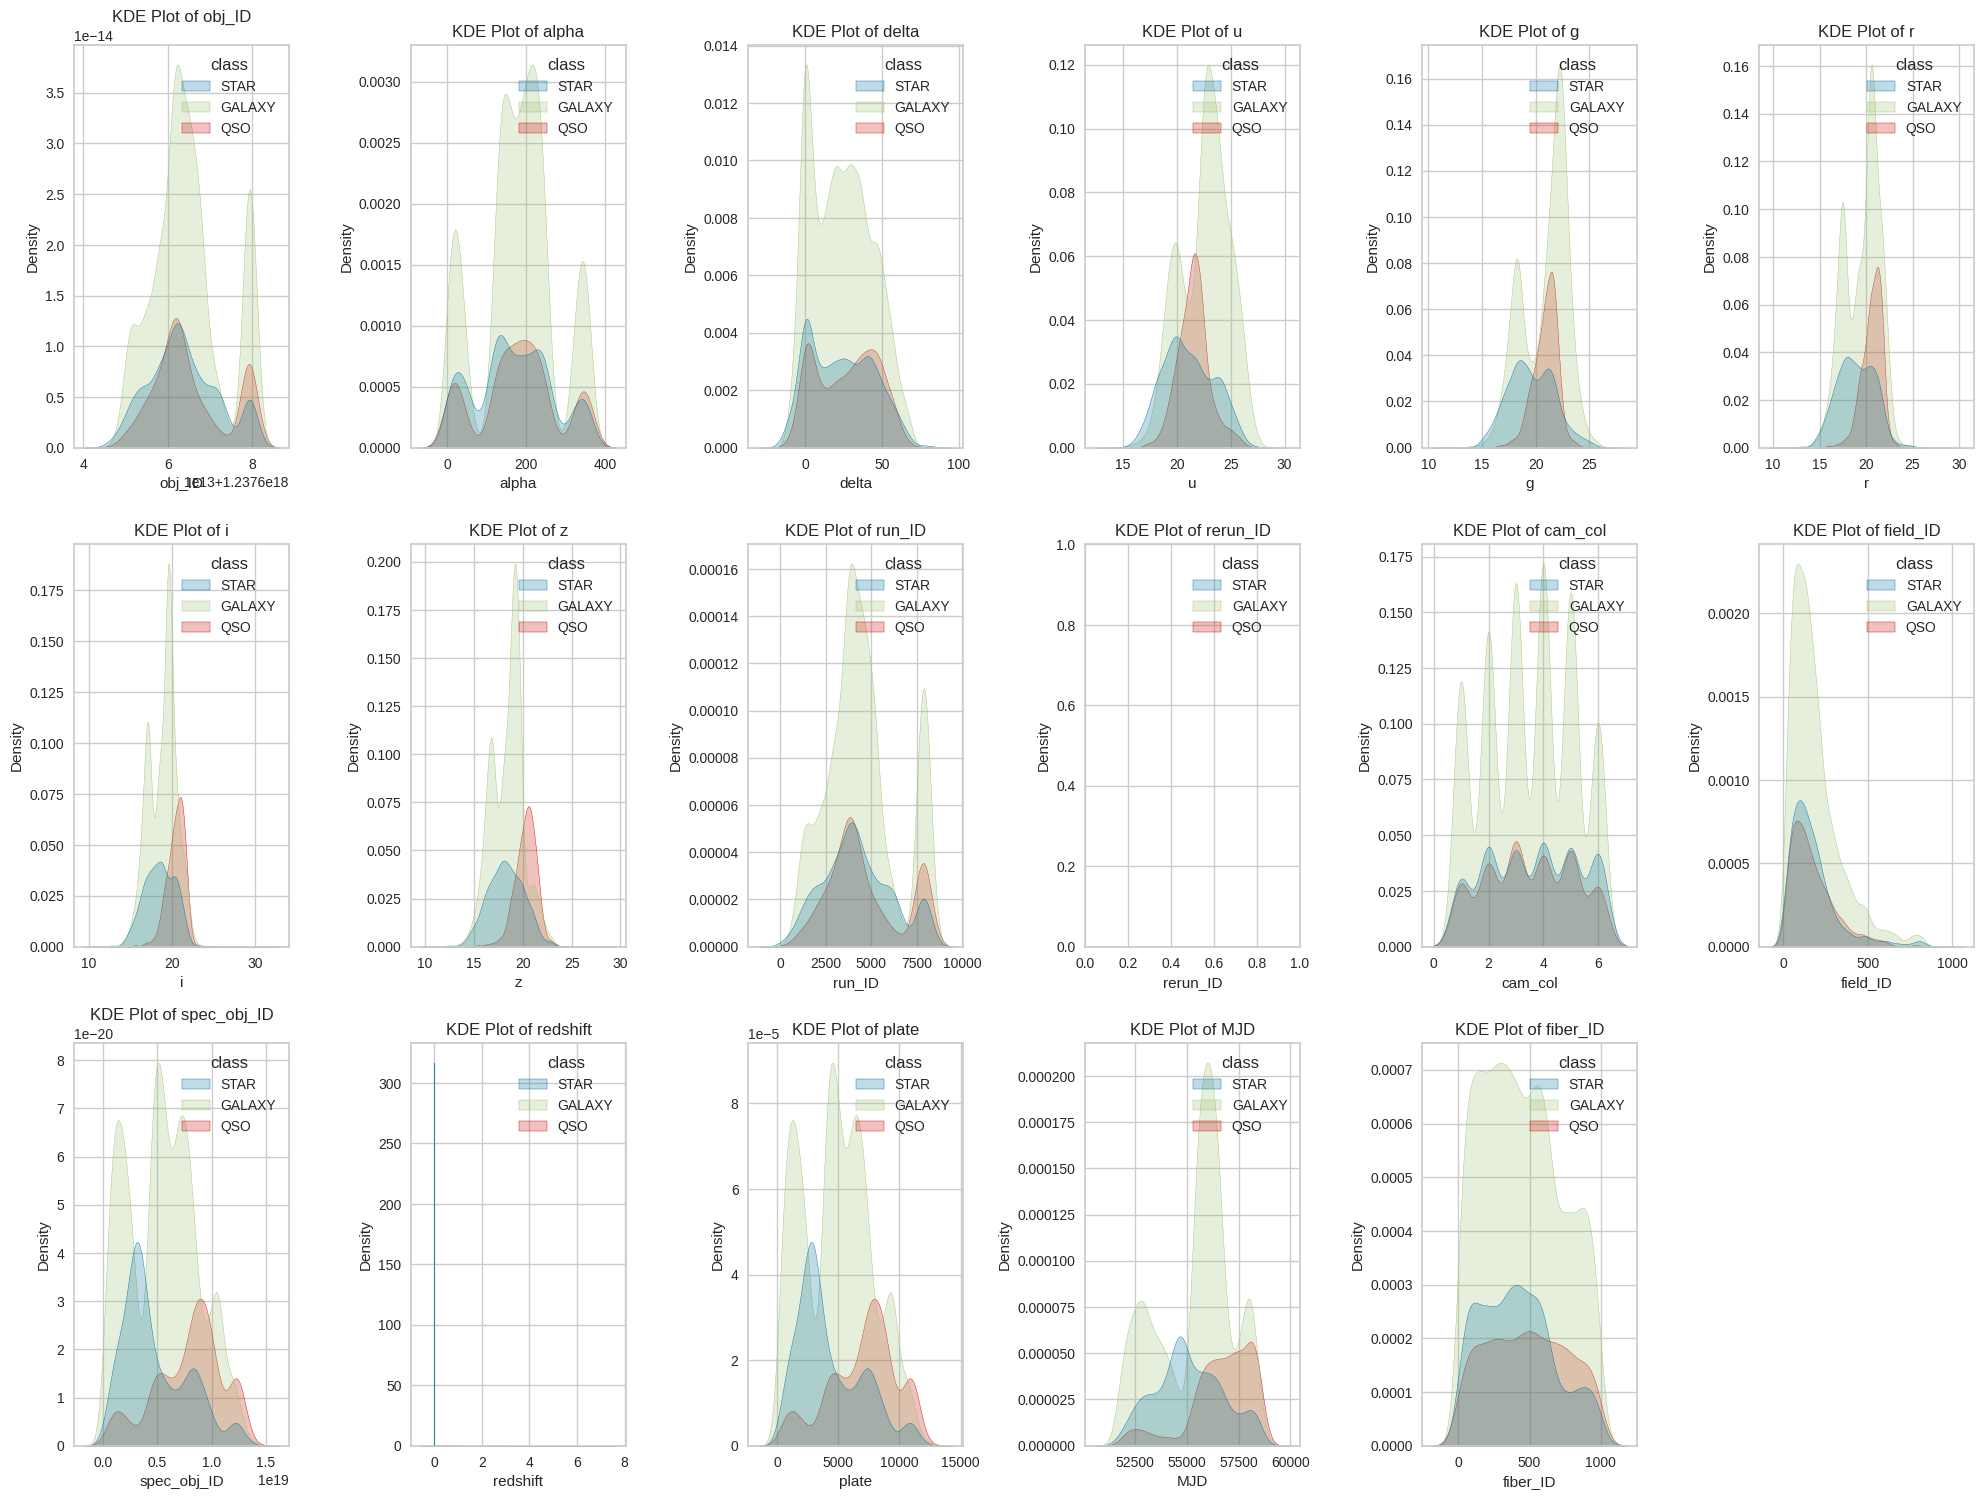

In [ ]:
plot_kde(stellar_df)

Box Plot:

Purpose: To visualize the distribution of numerical data, including outliers and quartiles.

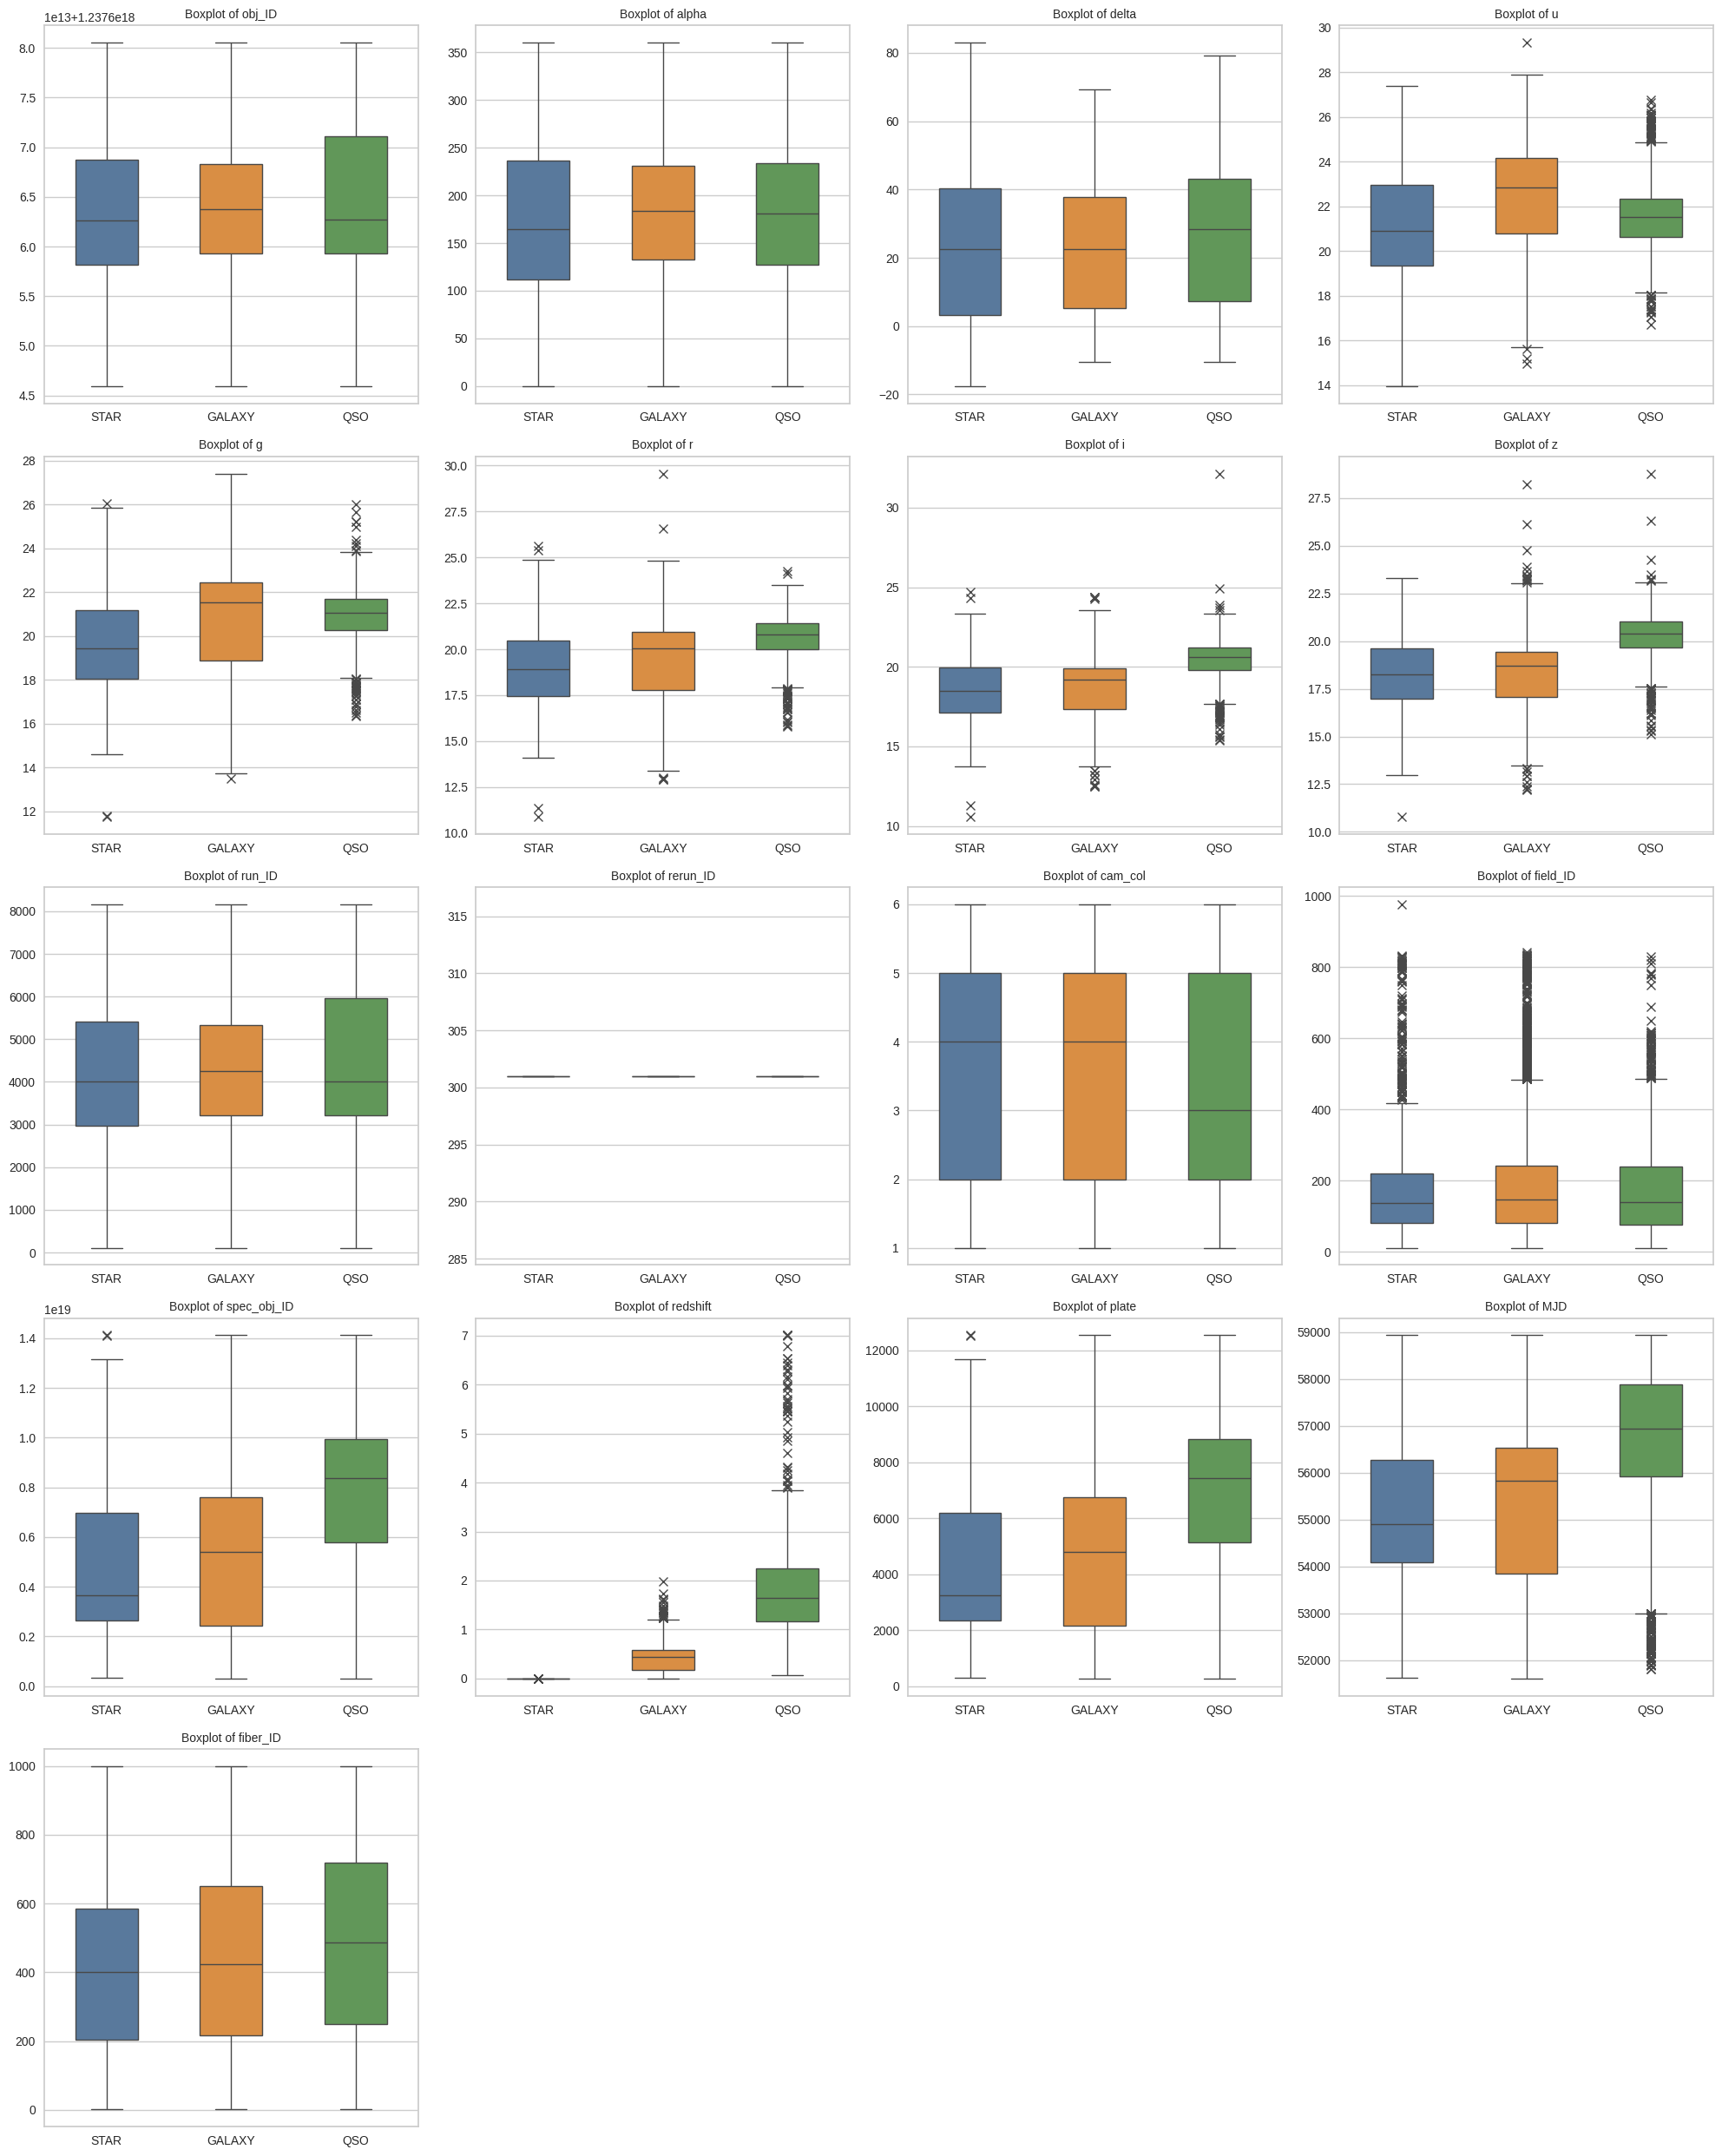

In [ ]:
def plot_grouped_boxplots(df):
    """
    Plots grouped Box Plots for all numerical columns in the dataset, 4 in a row.
    """
    # Automatically detect numerical columns
    features = df.select_dtypes(include=['float64', 'int64']).columns

    # Define rows and columns for the subplot grid
    plots_per_row = 4
    num_plots = len(features)
    num_rows = (num_plots + plots_per_row - 1) // plots_per_row  # Calculate rows required

    # Create subplots
    plt.figure(figsize=(20, num_rows * 5))  # Adjust height dynamically
    for i, feature in enumerate(features, 1):
        plt.subplot(num_rows, plots_per_row, i)  # Create a subplot in the grid
        sns.boxplot(x='class', y=feature, data=df,
                    width=0.5, flierprops={'marker': 'x'},
                    palette=['#4e79a7', '#f28e2b', '#59a14f'])
        plt.title(f'Boxplot of {feature}', fontsize=10)
        plt.xlabel(None)
        plt.ylabel(None)

    plt.tight_layout()
    plt.show()

# Example usage
plot_grouped_boxplots(stellar_df)

Violin Plots:

Purpose: To combine box plots and kernel density estimation, providing a more detailed view of the distribution.

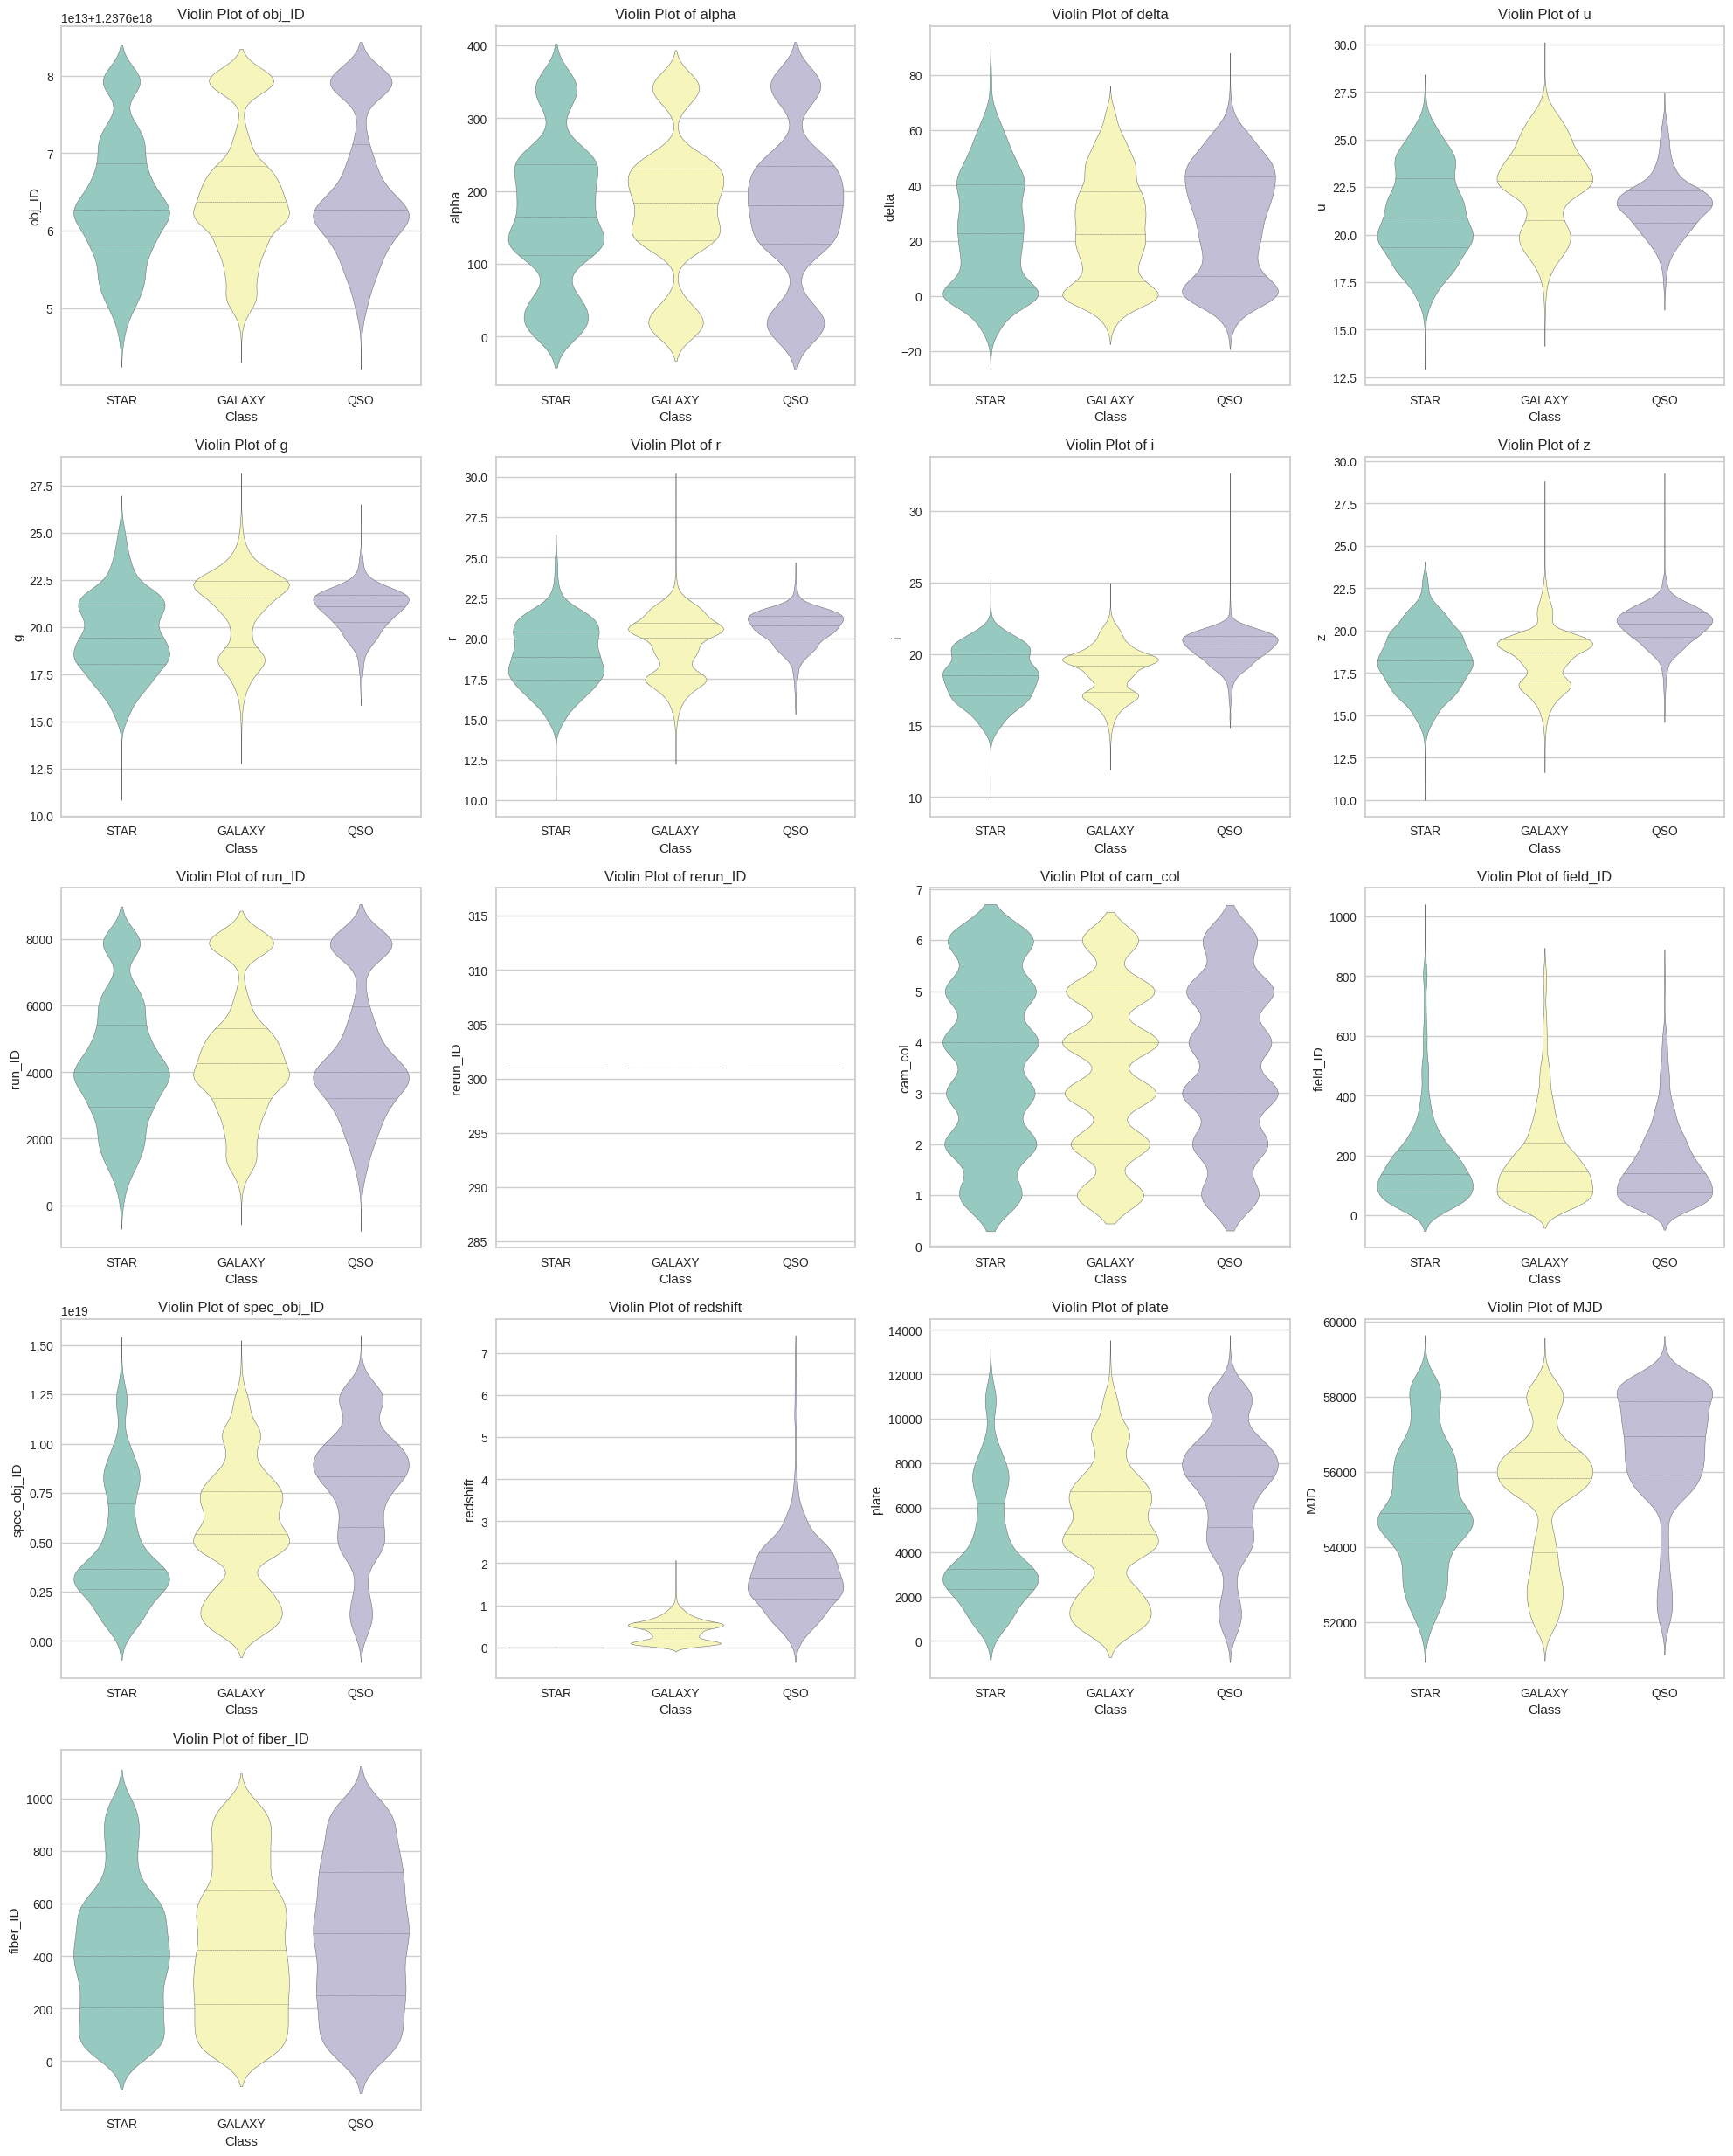

In [ ]:
def plot_grouped_violinplots(df):
    """
    Plots grouped Violin Plots for all numerical columns, grouped by class, 4 in a row.

    Parameters:
    df : DataFrame
        The dataset containing numerical columns and the target class column.
    """
    # Automatically detect numerical columns
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns

    # Set the number of plots per row
    plots_per_row = 4
    num_plots = len(num_cols)
    num_rows = (num_plots + plots_per_row - 1) // plots_per_row  # Calculate required rows

    # Create subplots
    fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(20, num_rows * 5))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    for idx, col in enumerate(num_cols):
        ax = axes[idx]
        sns.violinplot(x='class', y=col, data=df, ax=ax, palette='Set3', inner='quartile')
        ax.set_title(f'Violin Plot of {col}')
        ax.set_xlabel('Class')
        ax.set_ylabel(col)

    # Remove any unused subplots
    for idx in range(num_plots, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

# Example usage
plot_grouped_violinplots(stellar_df)

###Bivariate Analysis

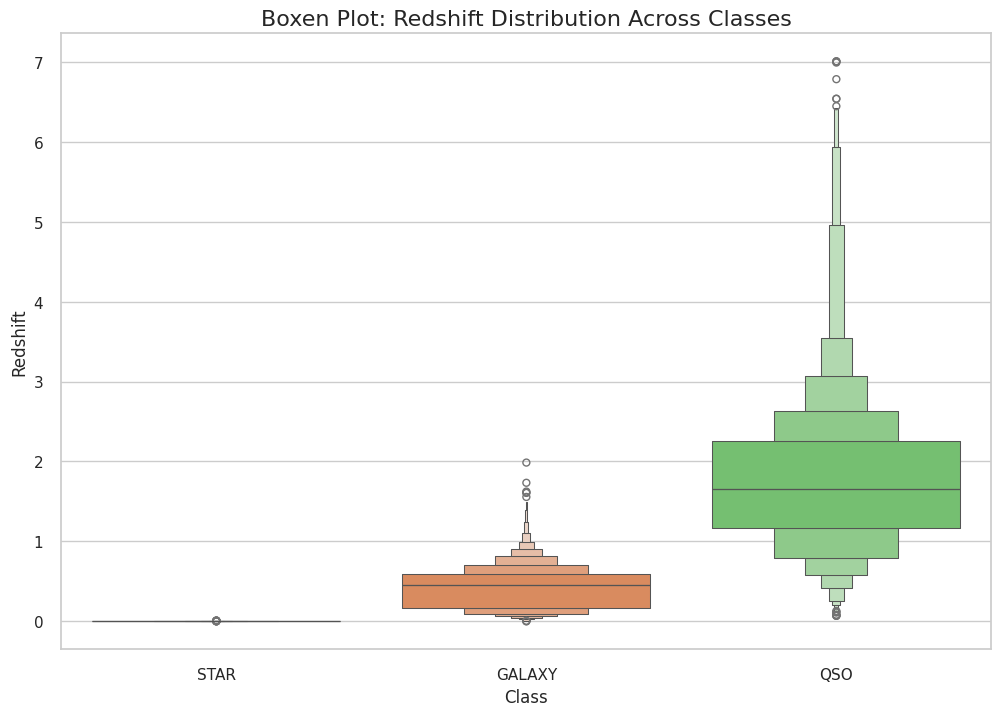

In [ ]:
# Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Set the plot style
sns.set(style="whitegrid")

# Create the boxen plot
plt.figure(figsize=(12, 8))
sns.boxenplot(data=stellar_df, x="class", y="redshift", palette="muted")
plt.title("Boxen Plot: Redshift Distribution Across Classes", fontsize=16)
plt.xlabel("Class")
plt.ylabel("Redshift")
plt.show()


##Multivariate Analysis

###Pairplots for multivariate analysis:

###Purpose: To visualize the relationship between pairs of features.

Pairplot and correlation plot for columns - alpha, delta, and redshift.

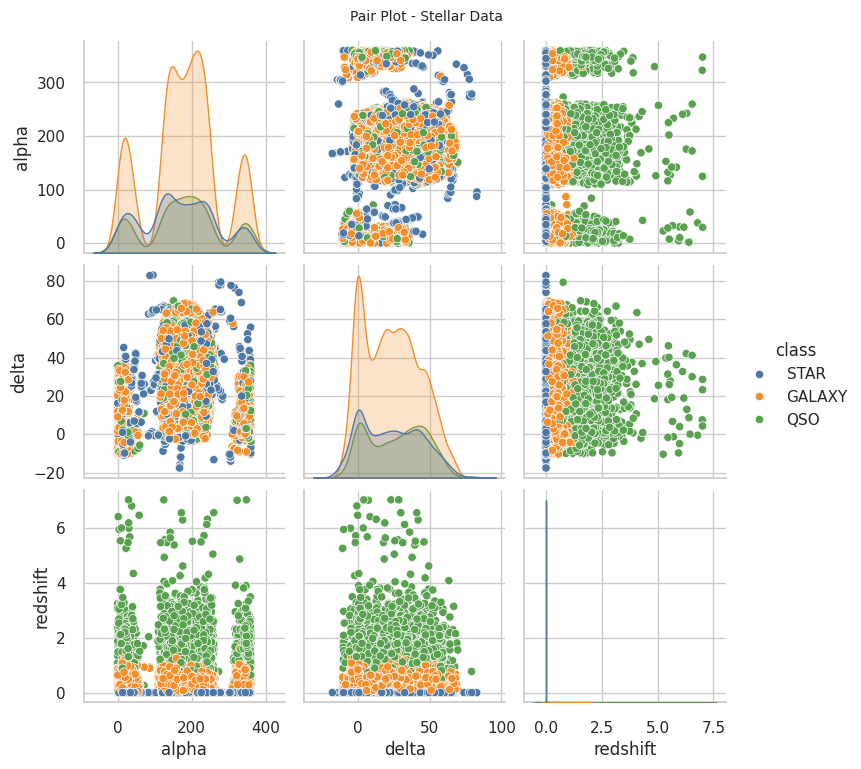

In [ ]:
g = sns.pairplot(data=stellar_df[['alpha', 'delta', 'redshift', 'class']],
                 hue='class', palette=['#4e79a7', '#f28e2b', '#59a14f'])
g.fig.suptitle(t='Pair Plot - Stellar Data', y=1.02, fontsize=10)
plt.show()

Clearly, there is no correlation in the above pairplot for the columns - alpha, delta and redshift.

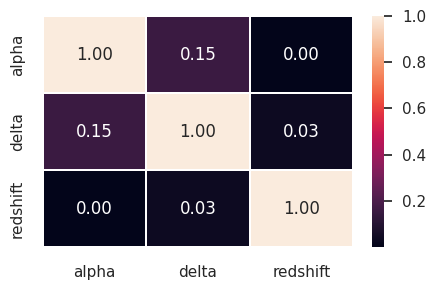

In [ ]:
plt.figure(figsize=(5, 3))
sns.heatmap(data=stellar_df[['alpha', 'delta', 'redshift']].corr(),
            annot=True, fmt='.2f', linewidths=0.1)
plt.show()

Pairplot and correlation plot for photometric filter columns - u, g, r, i, z.

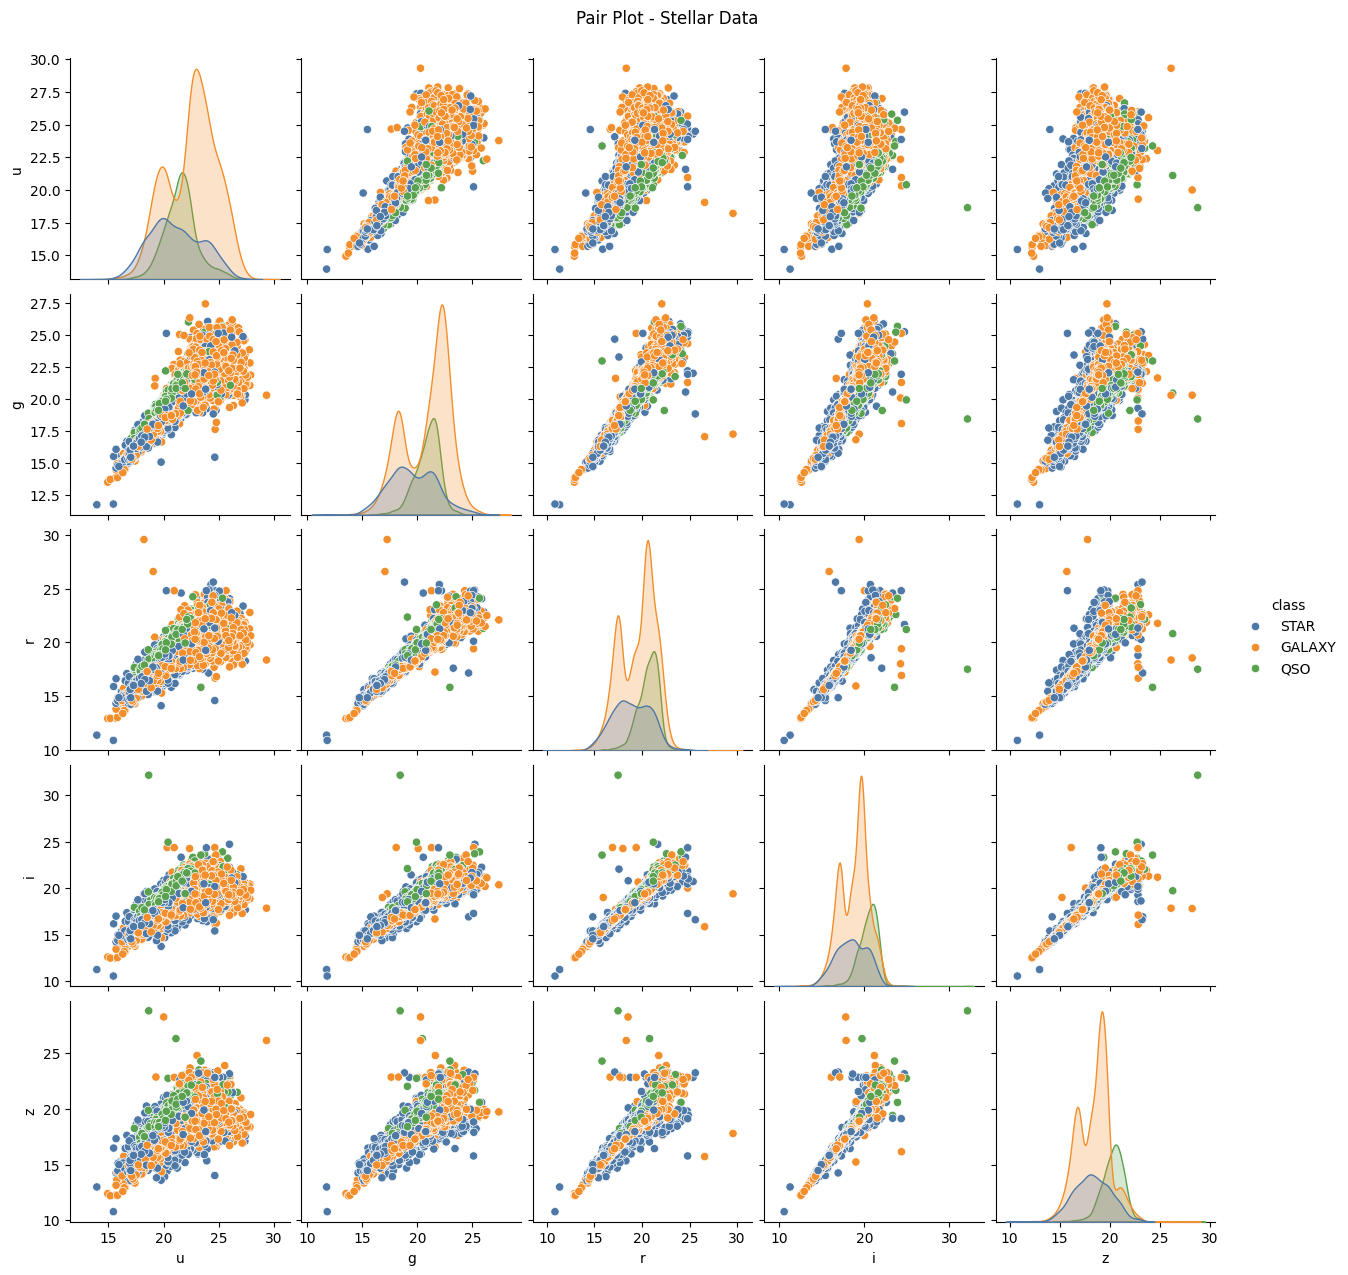

In [ ]:
g = sns.pairplot(data=stellar_df[['u', 'g', 'r', 'i', 'z', 'class']],
                 hue='class',
                 palette=['#4e79a7', '#f28e2b', '#59a14f'])
g.fig.suptitle(t='Pair Plot - Stellar Data', y=1.02)
plt.show()

There is a positive correlation among the photometric filter columns - u, g, r, i, z.

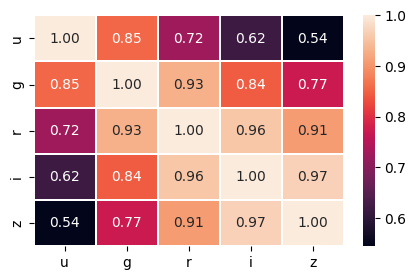

In [ ]:
plt.figure(figsize=(5, 3))
sns.heatmap(data=stellar_df[['u', 'g', 'r', 'i', 'z']].corr(),
            annot=True, fmt='.2f', linewidths=0.1)
plt.show()

##3D Space Object Location Visualization

Interpretation of the Plot

This 3D scatter plot graphically presents the various positions of objects in three-dimensional space. Each point corresponds to coordinates determined by the Right Ascension, Declination, and Redshift values. Colors represent the classes of objects.

In [ ]:
stellar_df_not_encoded = stellar_df.copy()
stellar_df_not_encoded.drop(['class'], axis=1, inplace=True)

In [ ]:
LE = LabelEncoder()
stellar_df['class'] = LE.fit_transform(stellar_df['class'])

for original, encoded in zip(LE.classes_, range(len(LE.classes_))):
    print(f"{original} -> {encoded}")

# Also show the count of each class
print("\nCount of each class:")
print(stellar_df['class'].value_counts())

GALAXY -> 0
QSO -> 1
STAR -> 2

Count of each class:
class
0    5945
2    2159
1    1896
Name: count, dtype: int64


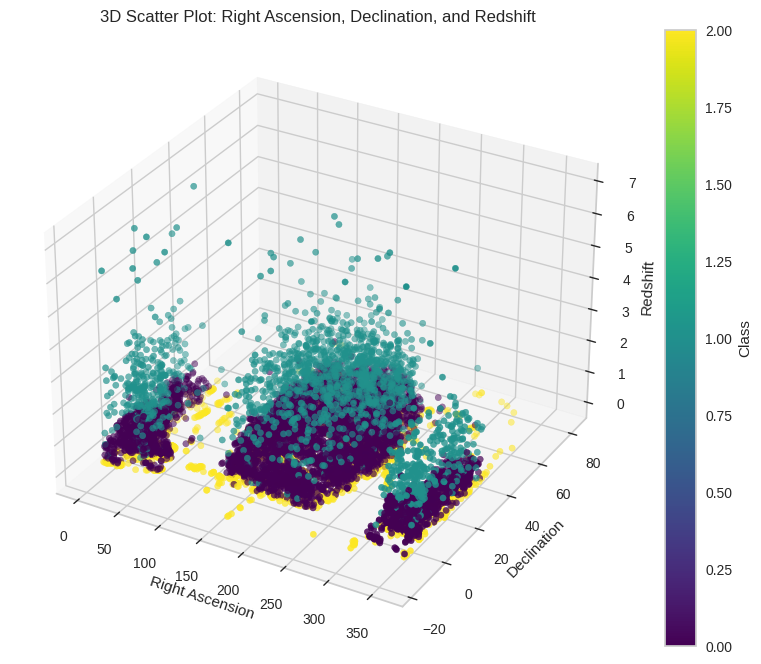

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter plot with Right Ascension, Declination, and Redshift
scatter = ax.scatter(stellar_df['alpha'], stellar_df['delta'], stellar_df['redshift'], c=stellar_df['class'], cmap='viridis')
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.set_zlabel('Redshift')
ax.set_title('3D Scatter Plot: Right Ascension, Declination, and Redshift')

# Adding color bar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Class')

plt.show()

#DATA CLEANING AND DATA PREPROCESSING

##FEATURE ENGINEERING

In [ ]:
corr = stellar_df.corr()

In [ ]:
corr["class"].sort_values()

,class
u,-0.276466
g,-0.229866
r,-0.076909
redshift,-0.044783
run_ID,-0.043422
obj_ID,-0.043419
alpha,-0.043184
field_ID,-0.032508
fiber_ID,-0.032006
spec_obj_ID,-0.011713


We can drop NAN value.

In [ ]:
stellar_df = stellar_df.drop('rerun_ID', axis=1)

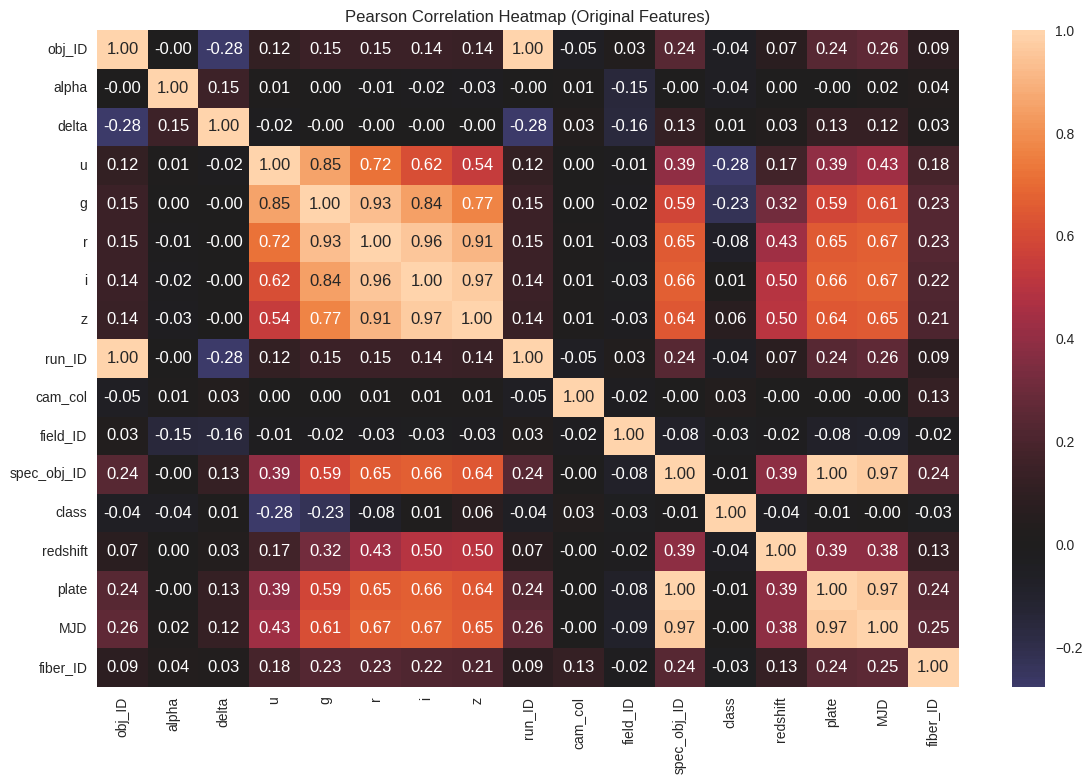

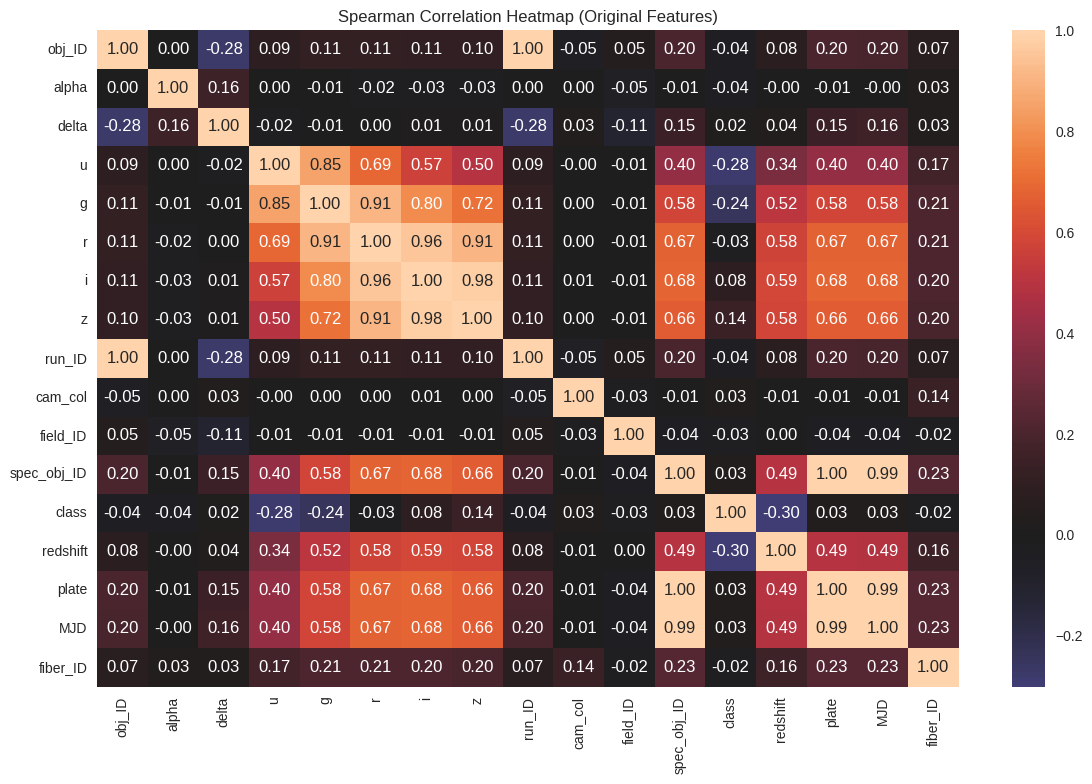

In [ ]:
# Pearson Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(stellar_df.corr(method='pearson'), annot=True, fmt='.2f', center=0)
plt.title('Pearson Correlation Heatmap (Original Features)')
plt.tight_layout()
plt.show()

# Spearman Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(stellar_df.corr(method='spearman'), annot=True, fmt='.2f', center=0)
plt.title('Spearman Correlation Heatmap (Original Features)')
plt.tight_layout()
plt.show()

Heat map correlation between variables

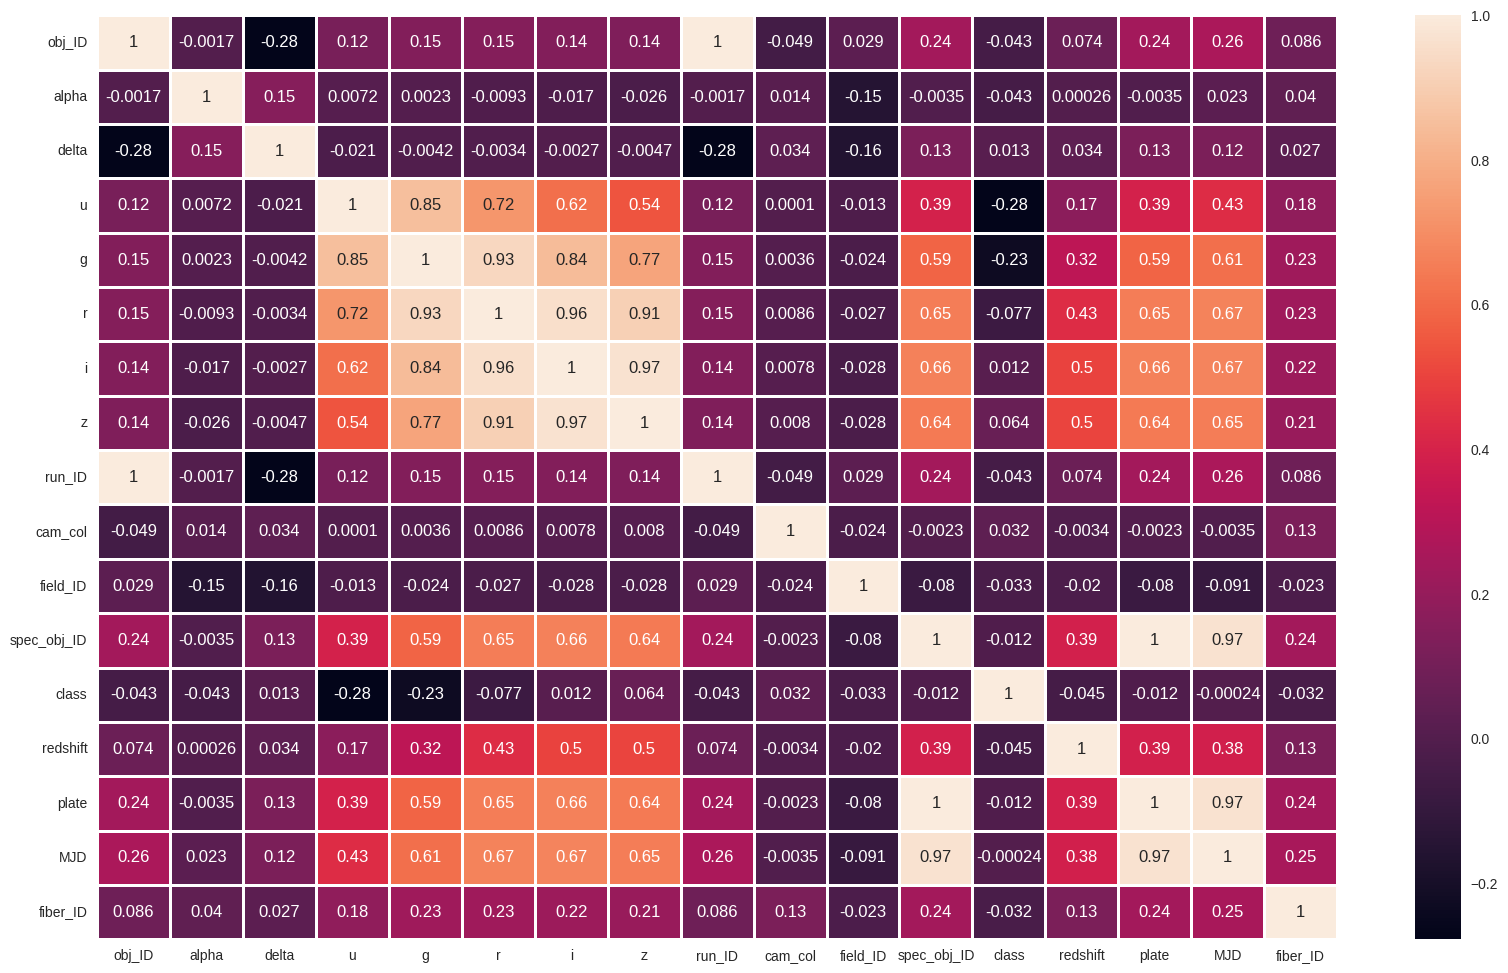

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(12,8))
sns.heatmap(stellar_df.corr(),annot=True,linewidths=1)
plt.show()

##FEATURE SCALING AND DIMENSIONALITY REDUCTION

In [ ]:
# Split the data into features (X) and target (y)

X = stellar_df.drop("class", axis=1) # Drop the target column to get the features

y = stellar_df["class"] # Set the target column

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



# PCA

pca = PCA(n_components=2)  # Reduce to 2 dimensions

X_pca = pca.fit_transform(X_scaled)

pca_comp = pca.components_



# LDA

lda = LinearDiscriminantAnalysis(n_components=2)  # Reduce to 2 dimensions

X_lda = lda.fit_transform(X_scaled, y)



# Print explained variance ratio for PCA

print(pca.explained_variance_ratio_)

[0.40391961 0.13020597]


In [ ]:
pca_comp

array([[-1.13488067e-01,  1.35856001e-04, -1.21812305e-02,
        -2.68426669e-01, -3.42627310e-01, -3.65106043e-01,
        -3.61880005e-01, -3.48769044e-01, -1.13487322e-01,
        -2.11719525e-03,  2.35168712e-02, -3.37018969e-01,
        -1.99996930e-01, -3.37018064e-01, -3.41441658e-01,
        -1.20188446e-01],
       [ 6.39630958e-01, -6.24046295e-02, -3.47153166e-01,
        -7.01839471e-02, -8.48819402e-02, -9.17577236e-02,
        -9.08831161e-02, -8.84872649e-02,  6.39635176e-01,
        -7.37898840e-02,  1.02338981e-01,  1.49093255e-02,
        -6.05771749e-02,  1.49093887e-02,  2.56219322e-02,
         7.77453770e-04]])

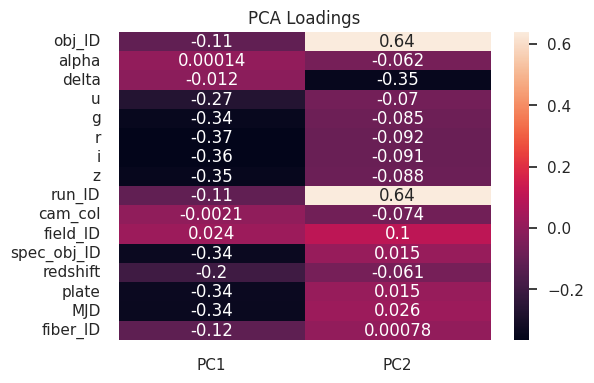

In [ ]:
loadings_df = pd.DataFrame(pca_comp.T, columns=['PC1', 'PC2'], index=X.columns)

plt.figure(figsize=(6, 4))

# Visualize the loadings

sns.heatmap(loadings_df, annot=True)

plt.title('PCA Loadings')

plt.show()

X = stellar_df[['u', 'g', 'r', 'i', 'z', 'spec_obj_ID', 'redshift', 'plate', 'MJD']]

In [ ]:
print(lda.explained_variance_ratio_)

[0.8792969 0.1207031]


From the PCA loadings heatmap, we should select features that have higher absolute values of loadings, meaning they contribute more to the principal components. Hence, I have selected the features below which meets the criteria.

In [ ]:
selected_features = ['u', 'g', 'r', 'i', 'z', 'spec_obj_ID', 'redshift', 'plate', 'MJD']

##Feature importance analysis (Random Forest), Recursive Feature Elimination (RFE), Principal Component Analysis (PCA), and statistical tests (Mutual Information & ANOVA F-Test)

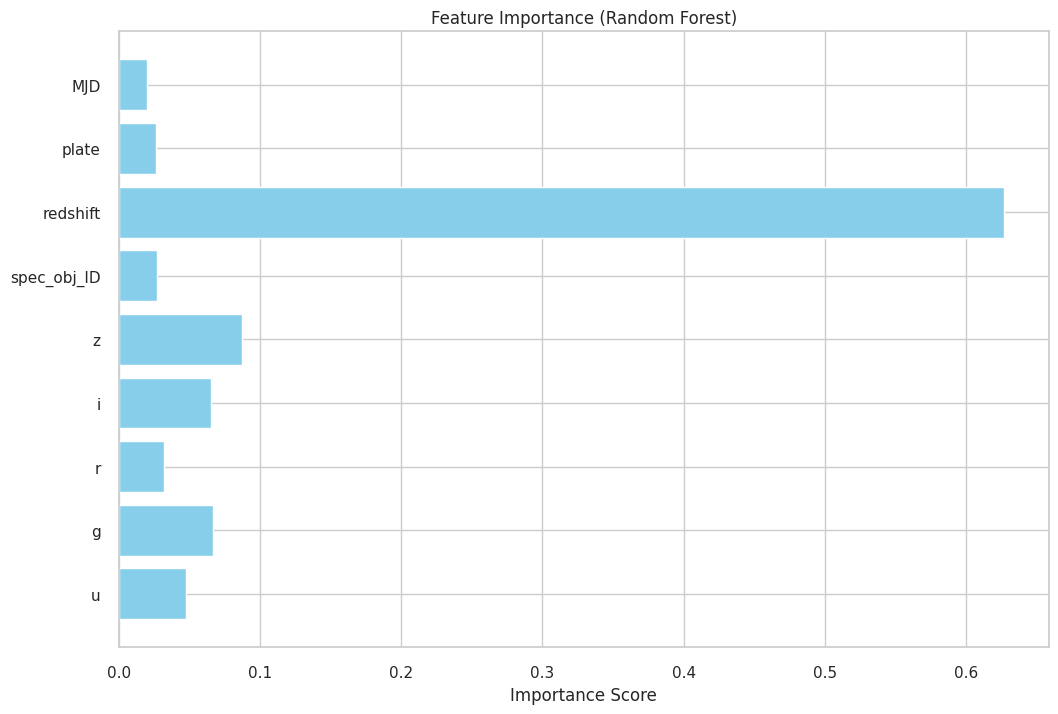

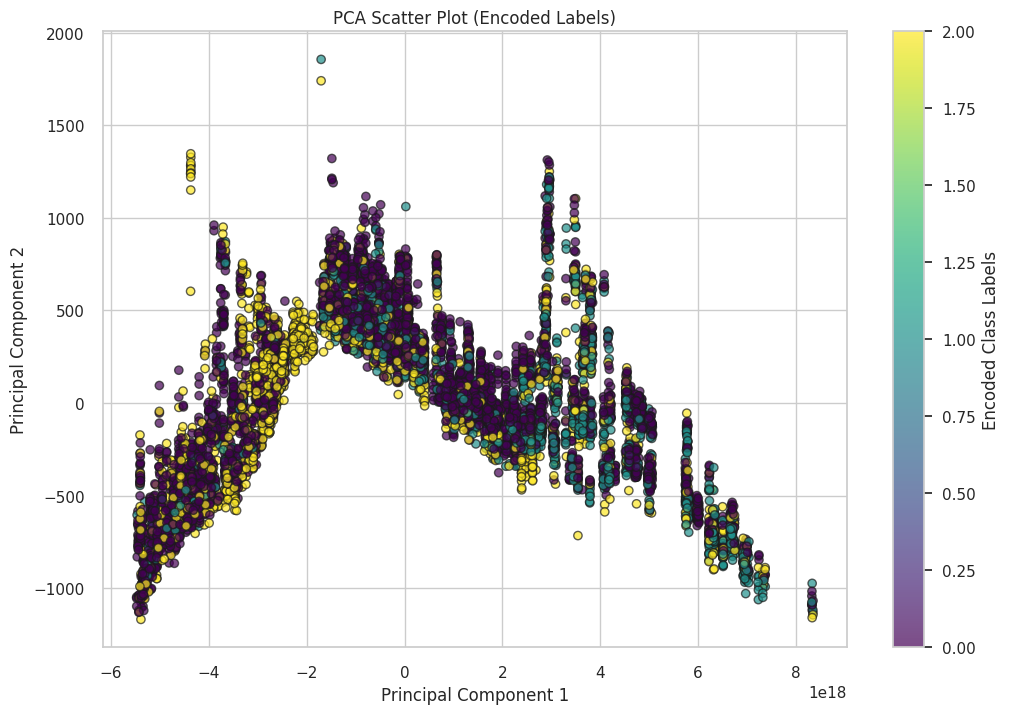

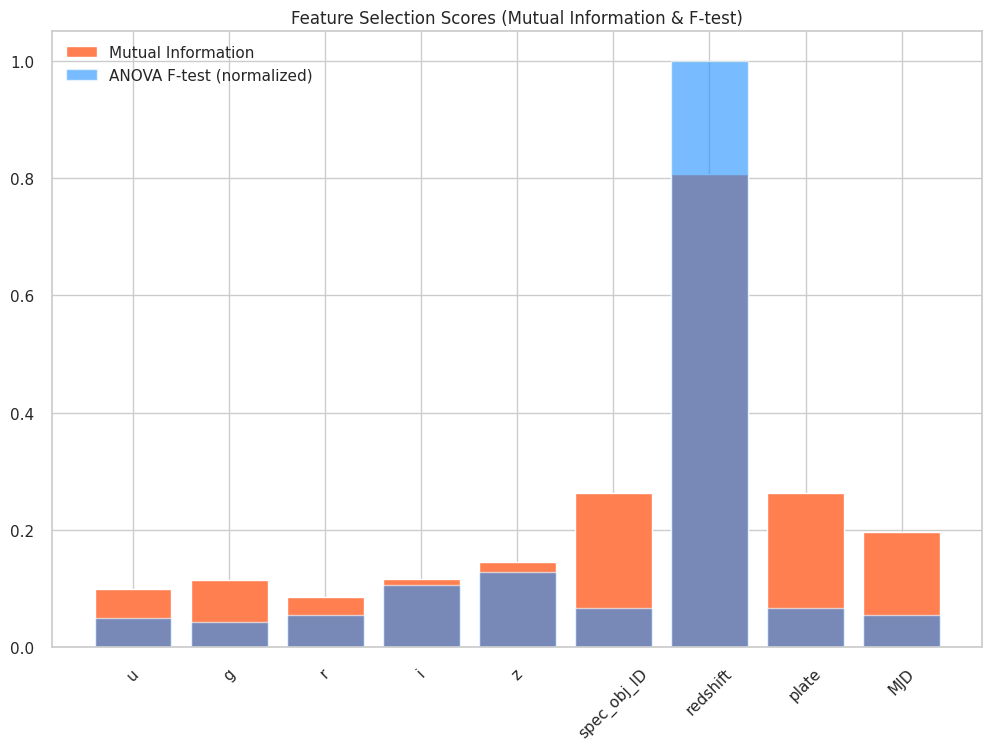

In [ ]:
# Define target and features
target = 'class'  # Assuming there is a target column named 'class' in the dataset
X = stellar_df[selected_features]
y = stellar_df[target]

# 1. Feature Importance using Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X, y)

feature_importances = rf_model.feature_importances_

# 2. Recursive Feature Elimination (RFE)
rfe = RFE(estimator=rf_model, n_features_to_select=5)
rfe.fit(X, y)

# 3. Principal Component Analysis (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 4. Statistical Tests
f_values, _ = f_classif(X, y)
mutual_info = mutual_info_classif(X, y)

# Visualization 1: Random Forest Feature Importance
plt.figure(figsize=(12, 8))
plt.barh(selected_features, feature_importances, color='skyblue')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

# Visualization 2: PCA Scatter Plot
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", edgecolor='k', alpha=0.7)
plt.title("PCA Scatter Plot (Encoded Labels)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Encoded Class Labels")
plt.show()

# Visualization 3: Feature Importance Summary
plt.figure(figsize=(12, 8))
plt.bar(selected_features, mutual_info, color='coral', label="Mutual Information")
plt.bar(selected_features, f_values / max(f_values), color='dodgerblue', alpha=0.6, label="ANOVA F-test (normalized)")
plt.legend()
plt.title("Feature Selection Scores (Mutual Information & F-test)")
plt.xticks(rotation=45)
plt.show()


###Let's see again Pearson Correlation Heatmap and Spearman Correlation Heatmap After Feature Selection.

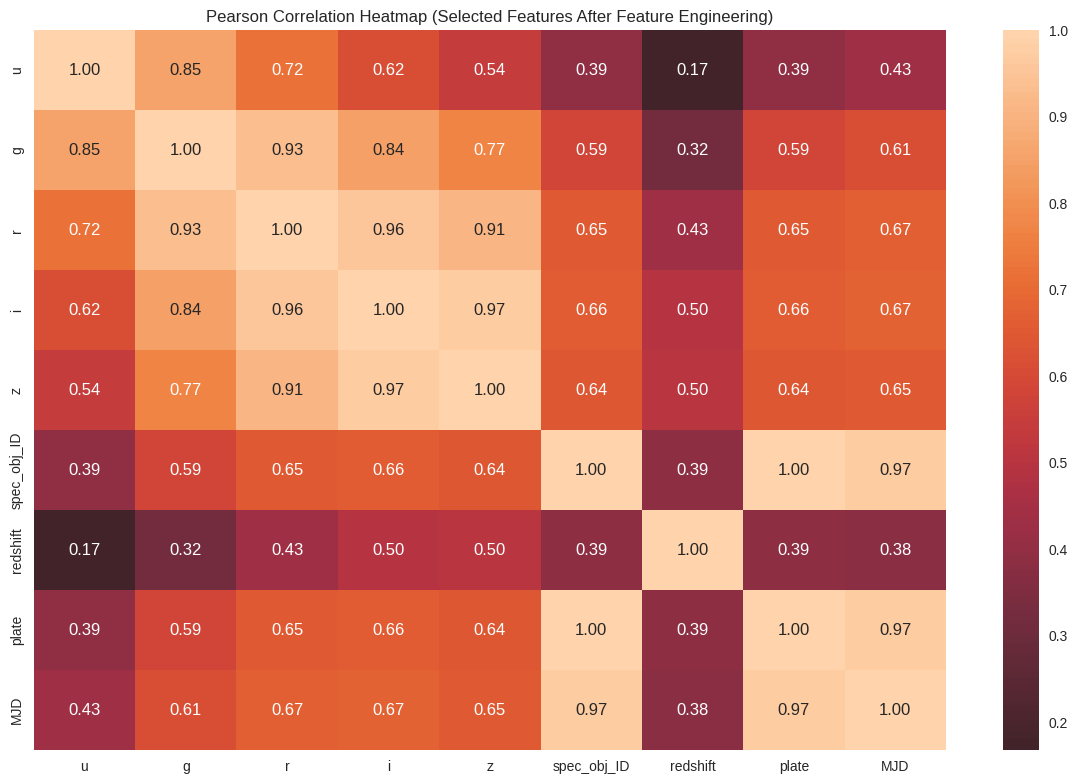

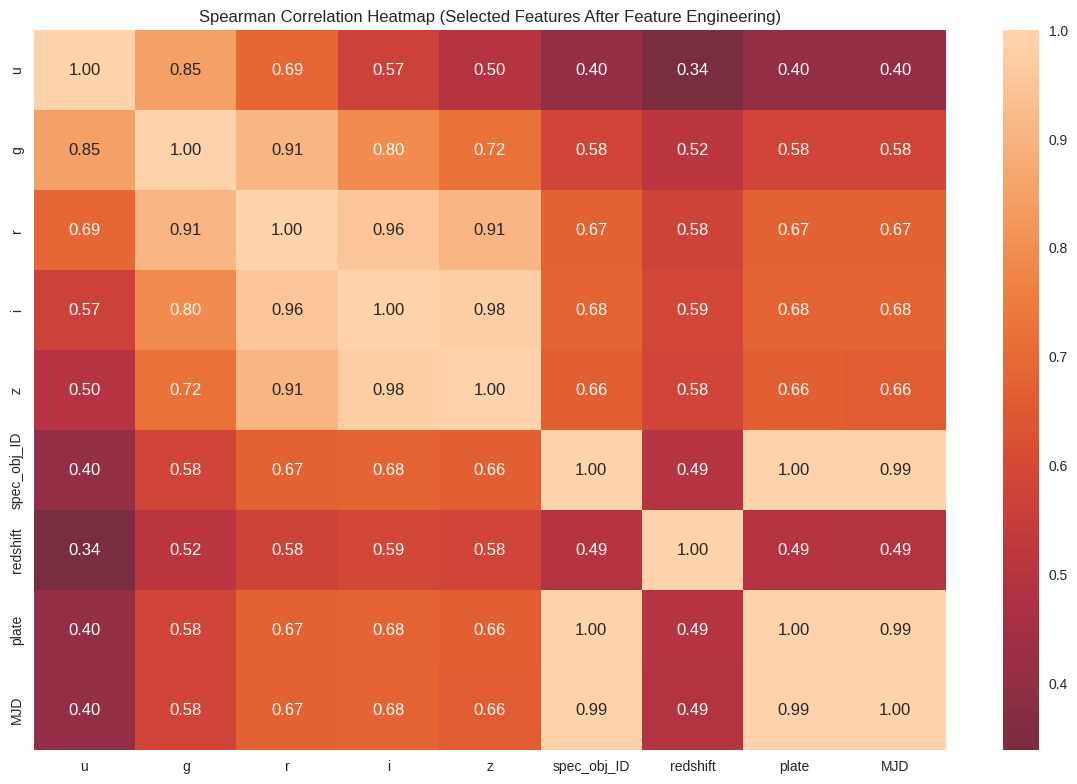

In [ ]:
# Pearson Correlation Heatmap (Selected Features)
plt.figure(figsize=(12, 8))
sns.heatmap(stellar_df[selected_features].corr(method='pearson'), annot=True, fmt='.2f', center=0)
plt.title('Pearson Correlation Heatmap (Selected Features After Feature Engineering)')
plt.tight_layout()
plt.show()

# Spearman Correlation Heatmap (Selected Features)
plt.figure(figsize=(12, 8))
sns.heatmap(stellar_df[selected_features].corr(method='spearman'), annot=True, fmt='.2f', center=0)
plt.title('Spearman Correlation Heatmap (Selected Features After Feature Engineering)')
plt.tight_layout()
plt.show()

HeatMap Correlation After Feature Engineering

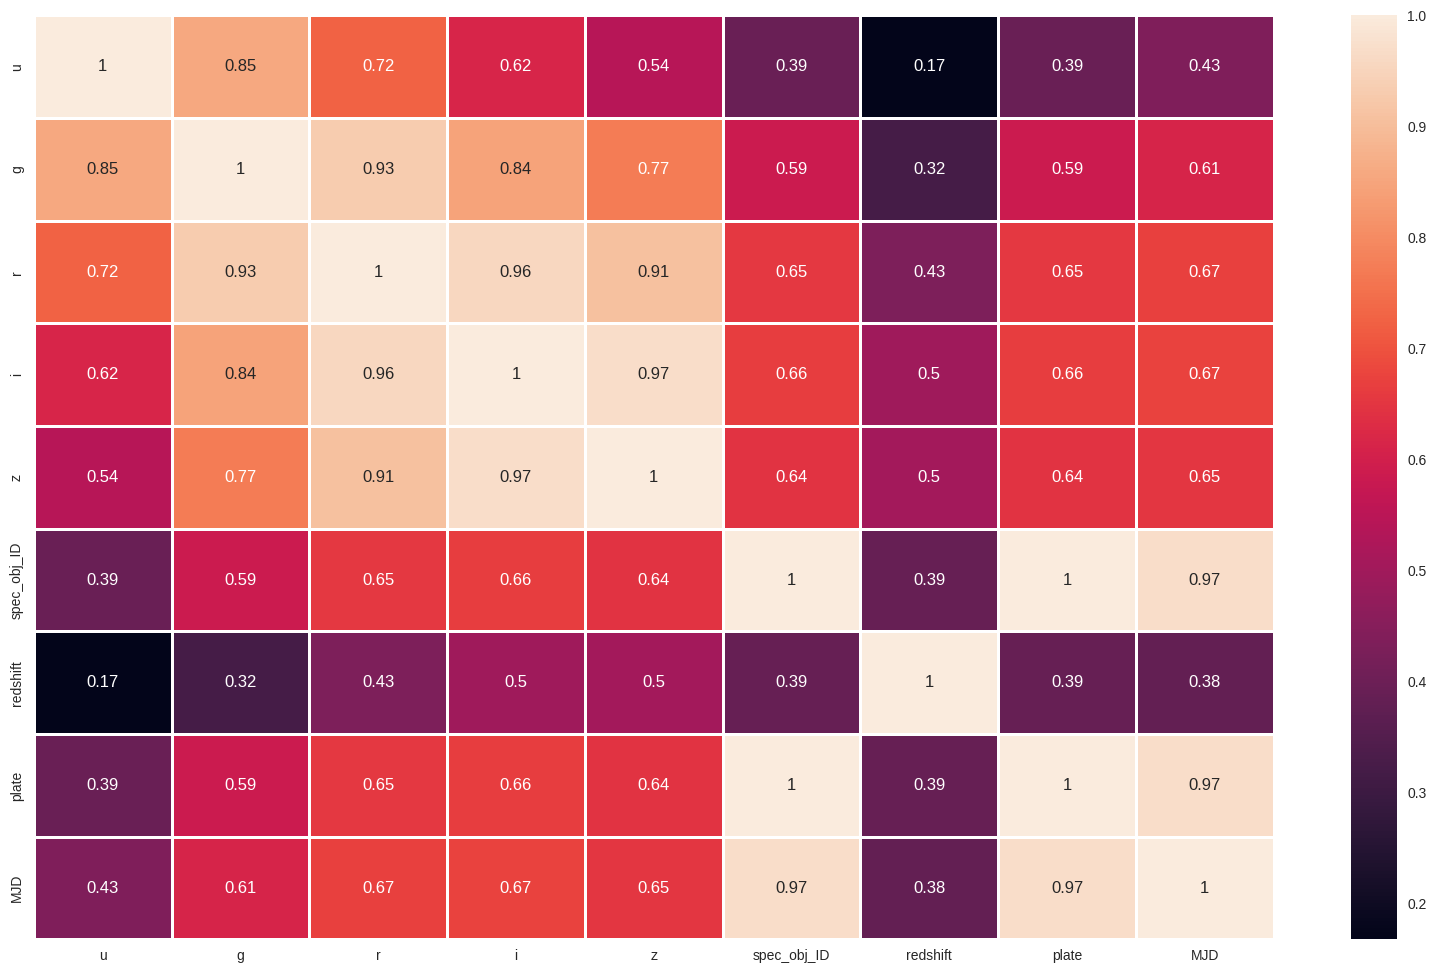

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(20,12))
sns.heatmap(stellar_df[selected_features].corr(),annot=True,linewidths=1)
plt.show()

Selected Features Distribution

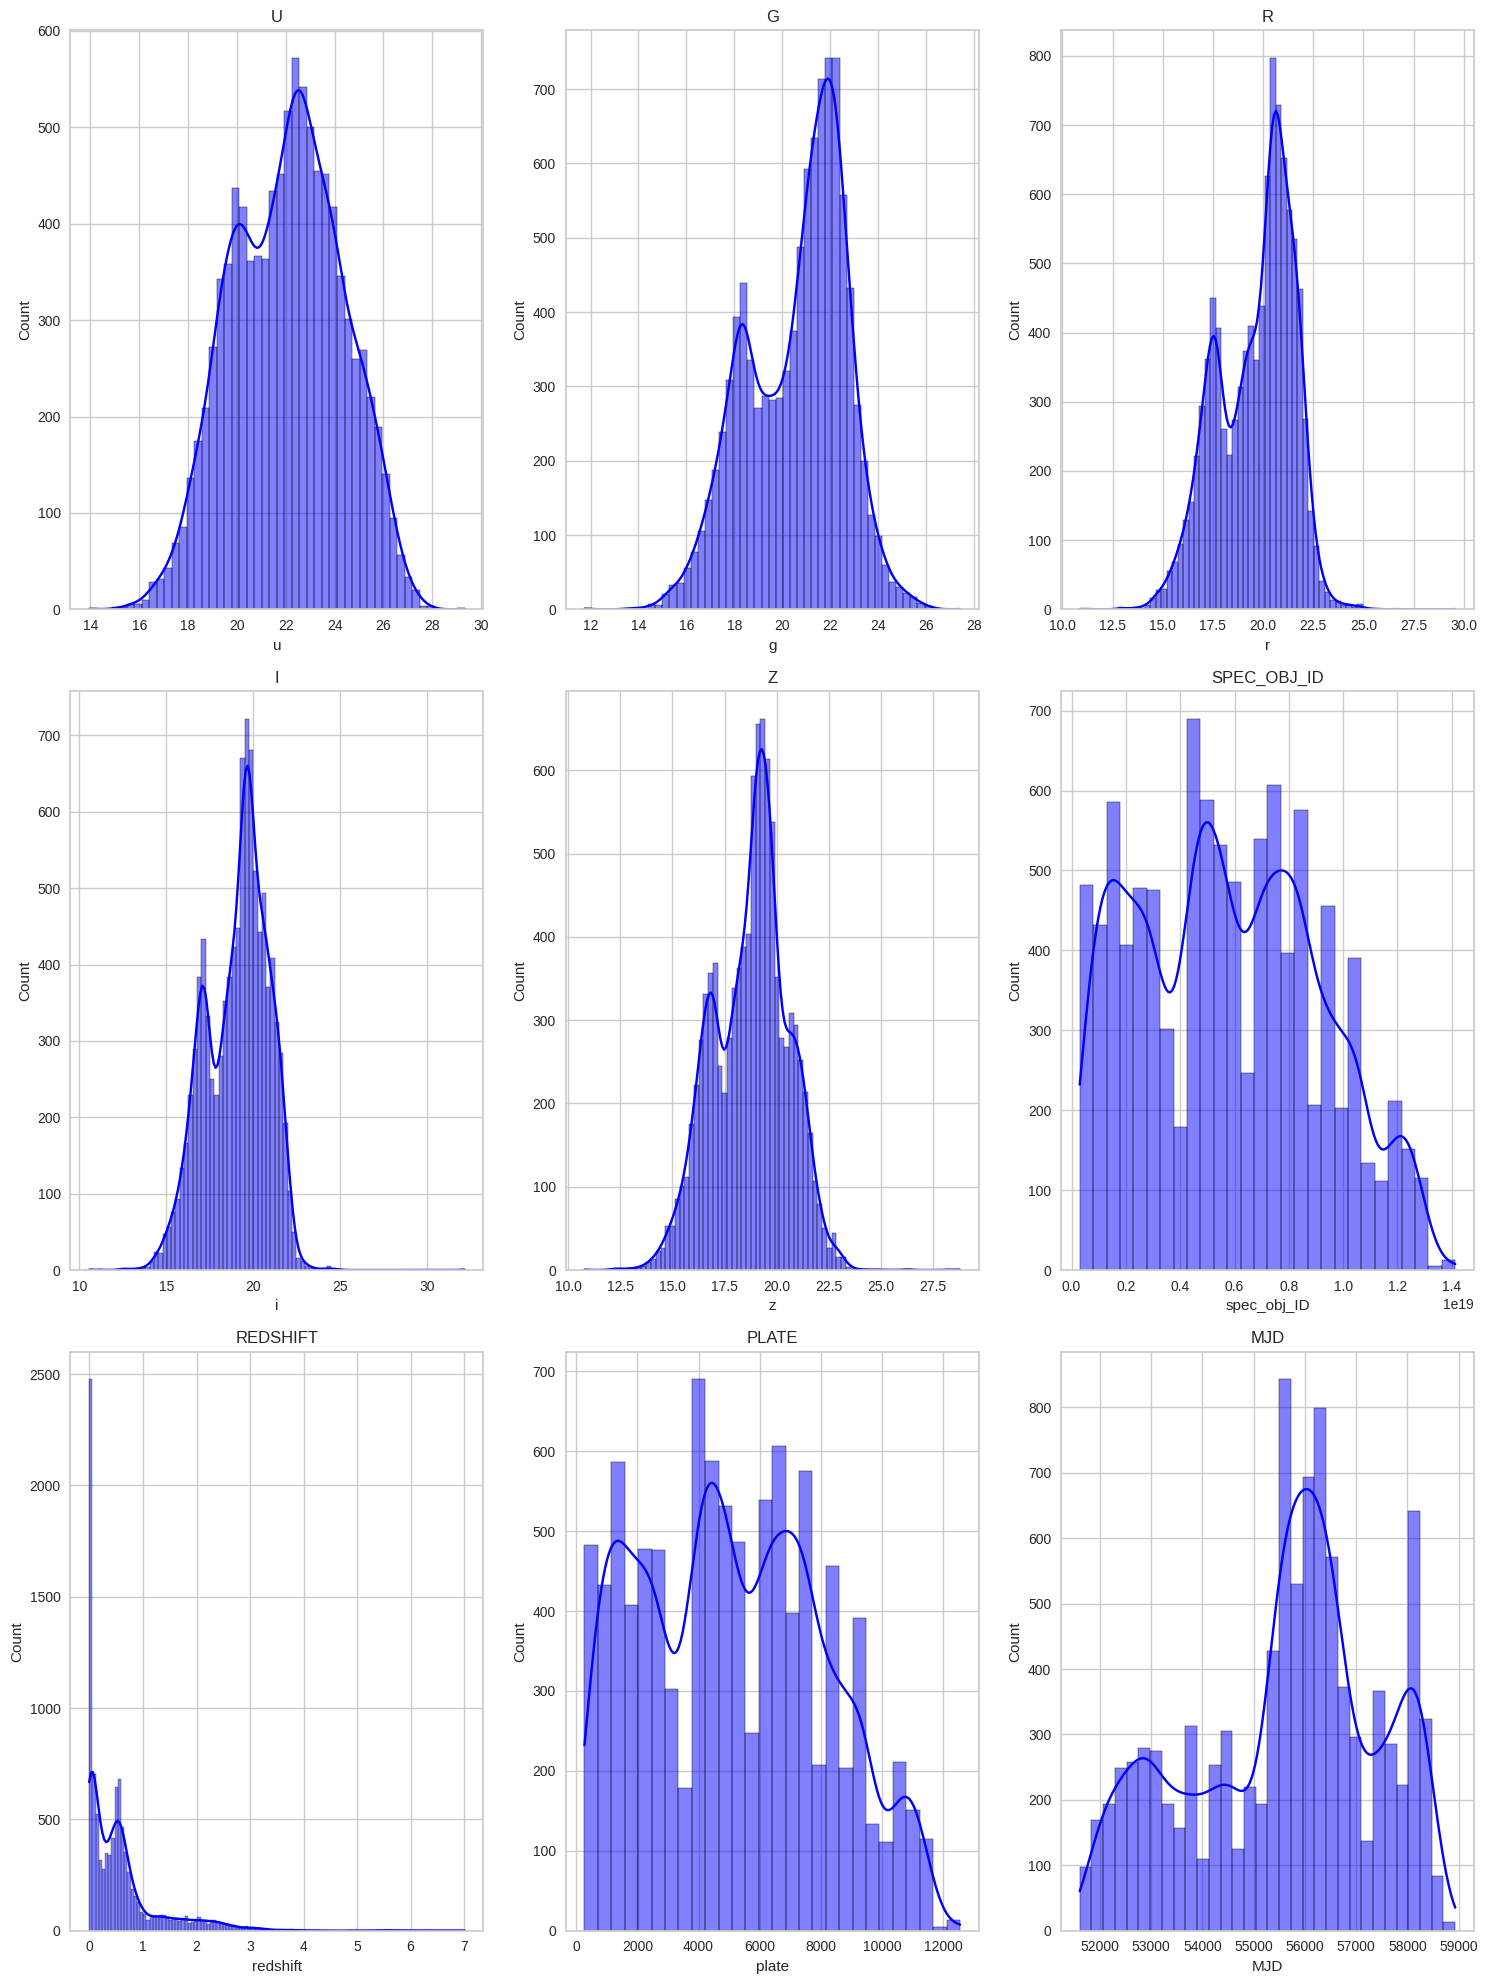

In [ ]:
num_plots = len(X.columns)
num_cols = 4  # Number of columns in the grid
num_rows = (num_plots - 1) // num_cols + 1

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 20))

for i, cols in enumerate(X.columns):
    row = i // num_cols
    col = i % num_cols
    sns.histplot(X[cols], kde=True, alpha=0.5, color='blue', ax=axes[row, col])
    axes[row, col].set_title(cols.upper())

for i in range(len(stellar_df), num_rows * num_cols):
    row = i // num_cols
    col = i % num_cols
    fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()

## IDENTIFYING AND ADDRESSING OUTLIERS

##ANOMALY DETECTION USING ISOLATION FOREST

Original Dataset Size: 10000
Number of Outliers Detected: 500
Remaining Dataset Size: 9500
Percentage of Outliers: 5.00%


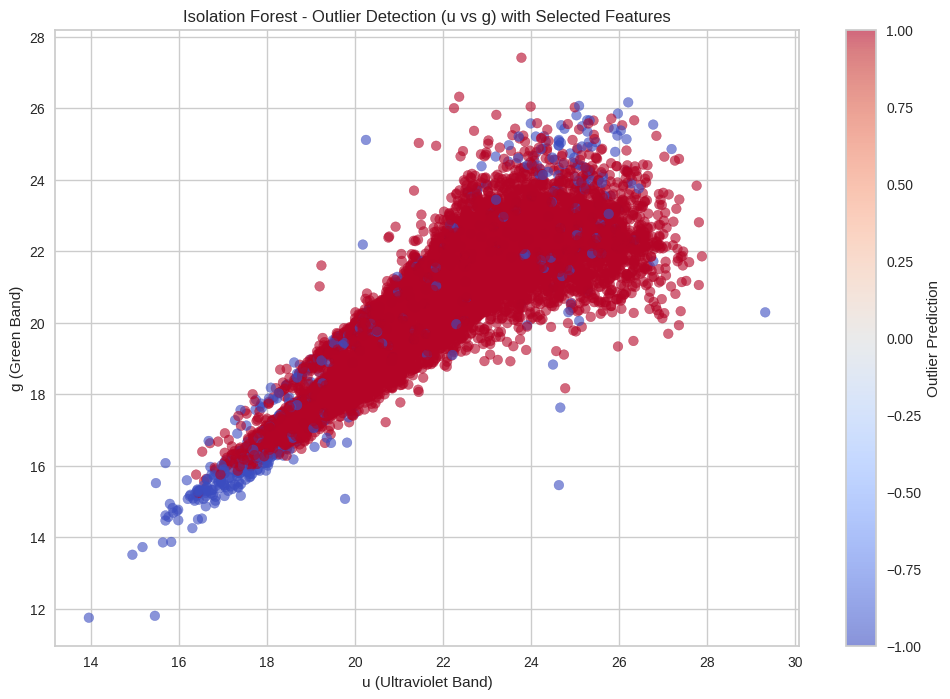

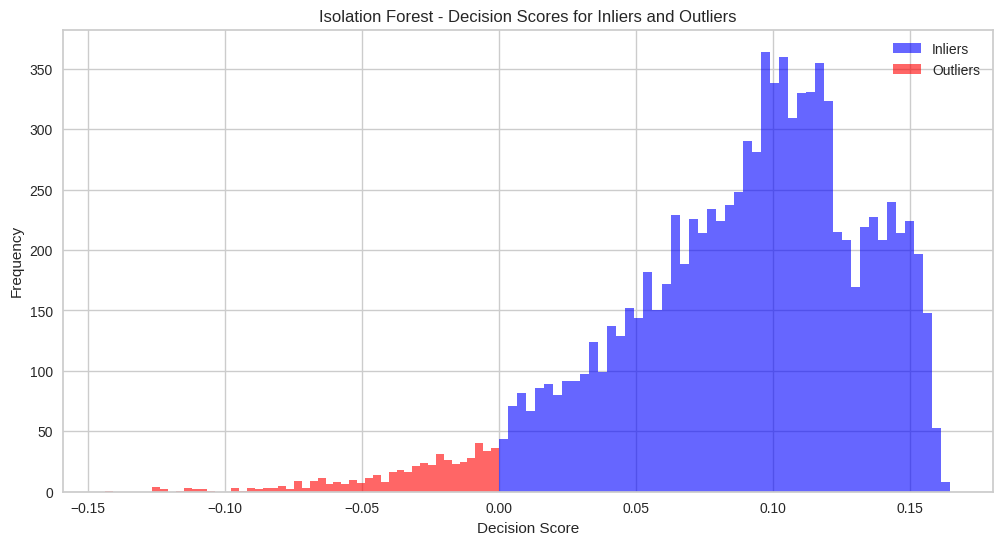

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.ensemble import IsolationForest

X = stellar_df[selected_features]
y = stellar_df['class']

# Step 3: Apply Isolation Forest on the selected features
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_pred = iso_forest.fit_predict(X)

# Create the cleaned dataset by filtering out the outliers
# X_cleaned = X[outlier_pred == 1]
# y_cleaned = y[outlier_pred == 1]
X_cleaned = X[outlier_pred == 1]
y_cleaned = y[outlier_pred == 1]

# Print the number of samples before and after cleaning
# print(f"Original Dataset Size: {len(X)}")
# print(f"Cleaned Dataset Size: {len(X_cleaned)}")

# Step 4: Count the number of outliers and inliers
num_outliers = (outlier_pred == -1).sum()
num_inliers = (outlier_pred == 1).sum()

# Calculate percentages
outlier_percentage = (num_outliers / len(X)) * 100
inlier_percentage = (num_inliers / len(X)) * 100

# Print the summary
print(f"Original Dataset Size: {len(X)}")
print(f"Number of Outliers Detected: {num_outliers}")
print(f"Remaining Dataset Size: {num_inliers}")
print(f"Percentage of Outliers: {outlier_percentage:.2f}%")

# Step 5: Visualize the outlier detection (u vs g)
plt.figure(figsize=(12, 8))
plt.scatter(X['u'], X['g'], c=outlier_pred, cmap='coolwarm', alpha=0.6)
plt.title("Isolation Forest - Outlier Detection (u vs g) with Selected Features")
plt.xlabel("u (Ultraviolet Band)")
plt.ylabel("g (Green Band)")
plt.colorbar(label="Outlier Prediction")
plt.show()

# Step 6: Plot the decision scores from the Isolation Forest
X['outlier_score'] = iso_forest.decision_function(X[selected_features])
X['outlier_label'] = outlier_pred

# Step 7: Visualize the decision scores for inliers and outliers
plt.figure(figsize=(12, 6))
plt.hist(X.loc[X['outlier_label'] == 1, 'outlier_score'], bins=50, alpha=0.6, color='blue', label='Inliers')
plt.hist(X.loc[X['outlier_label'] == -1, 'outlier_score'], bins=50, alpha=0.6, color='red', label='Outliers')
plt.title("Isolation Forest - Decision Scores for Inliers and Outliers")
plt.xlabel("Decision Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()


#TRAINING DATA AND TEST DATA SPLIT

In [ ]:
# X = stellar_df[selected_features]
# y = stellar_df['class']

In [ ]:
# Combine the cleaned features and target into a new DataFrame
cleaned_stellar_df = pd.concat([X_cleaned, y_cleaned], axis=1)

# Assign features and target variable for training
X = cleaned_stellar_df[selected_features]
y = cleaned_stellar_df['class']

# Print shapes to verify
print(f"Features Shape: {X.shape}")
print(f"Target Shape: {y.shape}")


Features Shape: (9500, 9)
Target Shape: (9500,)


The dataset is now 9,500 after takinng out outliers using Isolation Forest.

In [ ]:
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=747)


##APPLYING MACHINE LEARNING MODELS FOR STELLAR CLASSIFICATION

###FIRST WE START WITH SUPERVISED LEARNINNG MODELS

I actually tried out so many models and I've decided to go ahead with Random Forest and Extra Trees Classifiers. This is due to their robustness and ability to handle Stellar Classification Dataset effectively.

##Classifiers

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=747)

##**1. Random Forest Classifier**

In [ ]:
r_forest = RandomForestClassifier(random_state=747)
r_forest.fit(X_train,y_train)
predicted = r_forest.predict(X_test)
decoded_predictions = LE.inverse_transform(predicted)
score = r_forest.score(X_test, y_test)
rf_score_ = np.mean(score)

print('Accuracy : %.5f' % (rf_score_))

Accuracy : 0.97737


Confusion Matrix

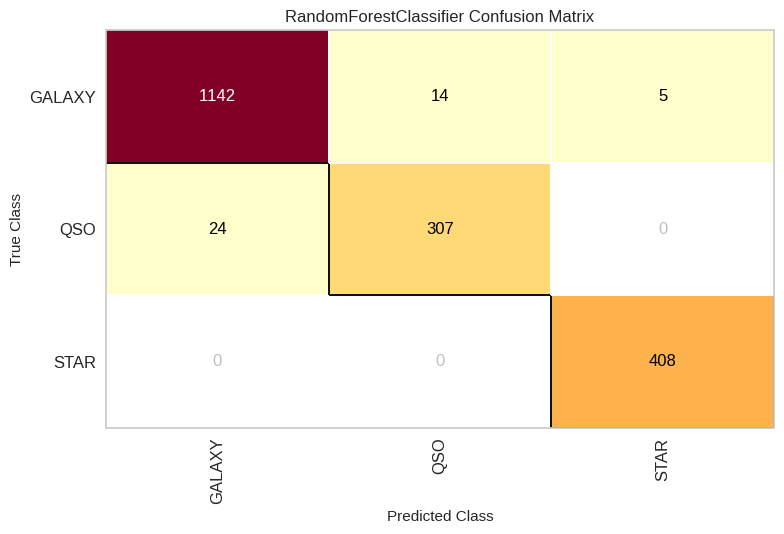

<Axes: title={'center': 'RandomForestClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
r_forest_cm = ConfusionMatrix(r_forest, classes=LE.classes_)

r_forest_cm.fit(X_train, y_train)
r_forest_cm.score(X_test, y_test)
r_forest_cm.show()

Classification Report

In [ ]:
y_test_decoded = LE.inverse_transform(y_test)
predicted_decoded = LE.inverse_transform(predicted)

# Generate the classification report
report = classification_report(y_test_decoded, predicted_decoded)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98      1161
         QSO       0.96      0.93      0.94       331
        STAR       0.99      1.00      0.99       408

    accuracy                           0.98      1900
   macro avg       0.97      0.97      0.97      1900
weighted avg       0.98      0.98      0.98      1900



ROC Curve

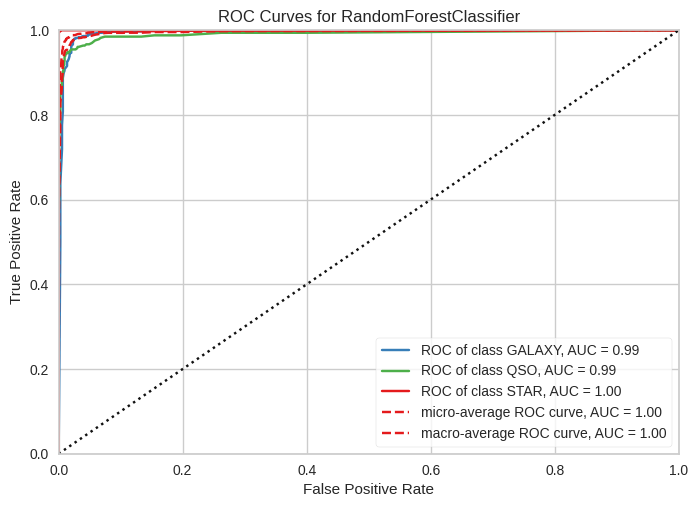

<Axes: title={'center': 'ROC Curves for RandomForestClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
visualizer = ROCAUC(r_forest, classes=LE.classes_)

set_palette('bold')

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

Class Prediction Error

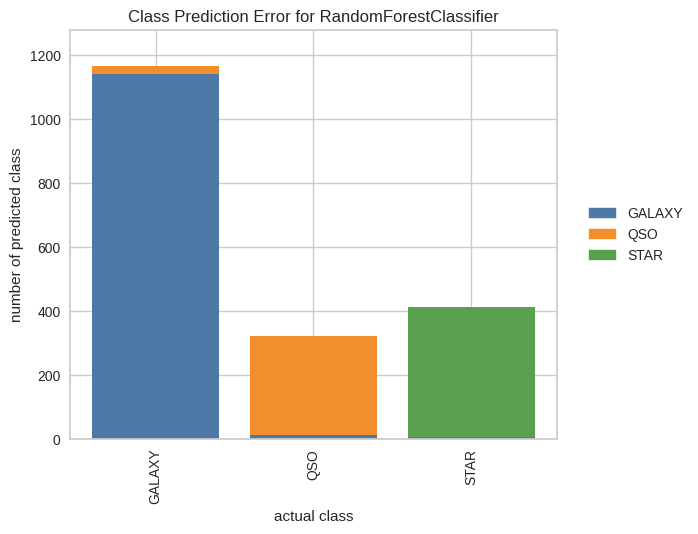

<Axes: title={'center': 'Class Prediction Error for RandomForestClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [ ]:
visualizer = ClassPredictionError(r_forest, classes=LE.classes_)
palette = ['#4e79a7', '#f28e2b', '#59a14f']

set_palette(palette)

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

##**2. ExtraTreesClassifier**

In [ ]:
# Initialize and train the ExtraTreesClassifier
et_classifier = ExtraTreesClassifier(random_state=747)
et_classifier.fit(X_train, y_train)

# Make predictions and decode them back to original class names
et_predicted = et_classifier.predict(X_test)
et_decoded_predictions = LE.inverse_transform(et_predicted)

# Calculate accuracy
et_score = et_classifier.score(X_test, y_test)
et_accuracy = np.mean(et_score)
print('Accuracy: %.5f' % (et_accuracy))

Accuracy: 0.97474


Confusion Matrix

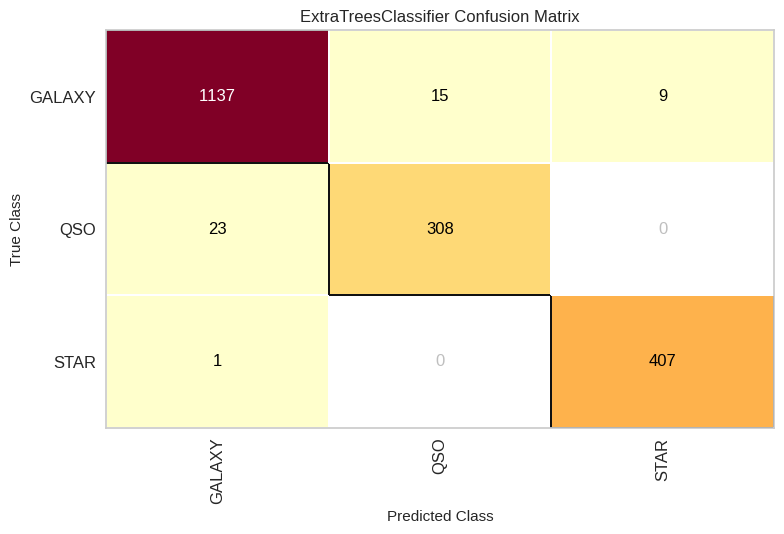

<Axes: title={'center': 'ExtraTreesClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
# Generate the Confusion Matrix
et_cm = ConfusionMatrix(et_classifier, classes=LE.classes_)
et_cm.fit(X_train, y_train)
et_cm.score(X_test, y_test)
et_cm.show()

Classification Report

In [ ]:
# Decode the test labels and predictions
et_y_test_decoded = LE.inverse_transform(y_test)
et_predicted_decoded = LE.inverse_transform(et_predicted)

# Generate the classification report
et_report = classification_report(et_y_test_decoded, et_predicted_decoded)
print("Classification Report:")
print(et_report)

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98      1161
         QSO       0.95      0.93      0.94       331
        STAR       0.98      1.00      0.99       408

    accuracy                           0.97      1900
   macro avg       0.97      0.97      0.97      1900
weighted avg       0.97      0.97      0.97      1900



Class Prediction Error

ROC Curve

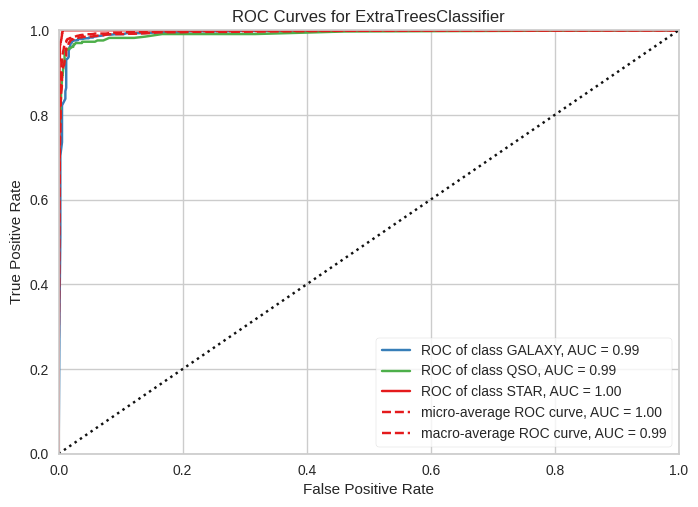

<Axes: title={'center': 'ROC Curves for ExtraTreesClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
# Plot the ROC Curve
et_roc = ROCAUC(et_classifier, classes=LE.classes_)
set_palette('bold')

et_roc.fit(X_train, y_train)
et_roc.score(X_test, y_test)
et_roc.show()

Class Prediction Error

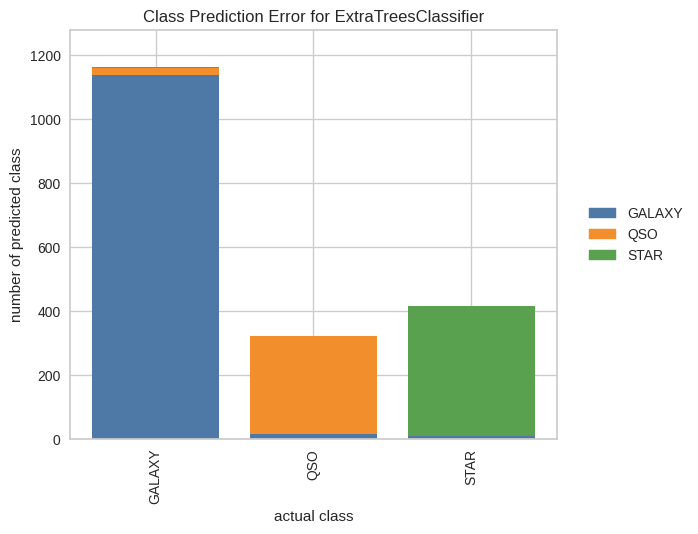

<Axes: title={'center': 'Class Prediction Error for ExtraTreesClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [ ]:
# Generate the Class Prediction Error plot
et_cpe = ClassPredictionError(et_classifier, classes=LE.classes_)
palette = ['#4e79a7', '#f28e2b', '#59a14f']
set_palette(palette)

et_cpe.fit(X_train, y_train)
et_cpe.score(X_test, y_test)
et_cpe.show()

##**3. KMeans Clusterinng**

##**Unsupervised Learning Model**

Again, I explored so many models before proceeding with KMeans Clustering.

In [ ]:
X.shape

(9500, 9)

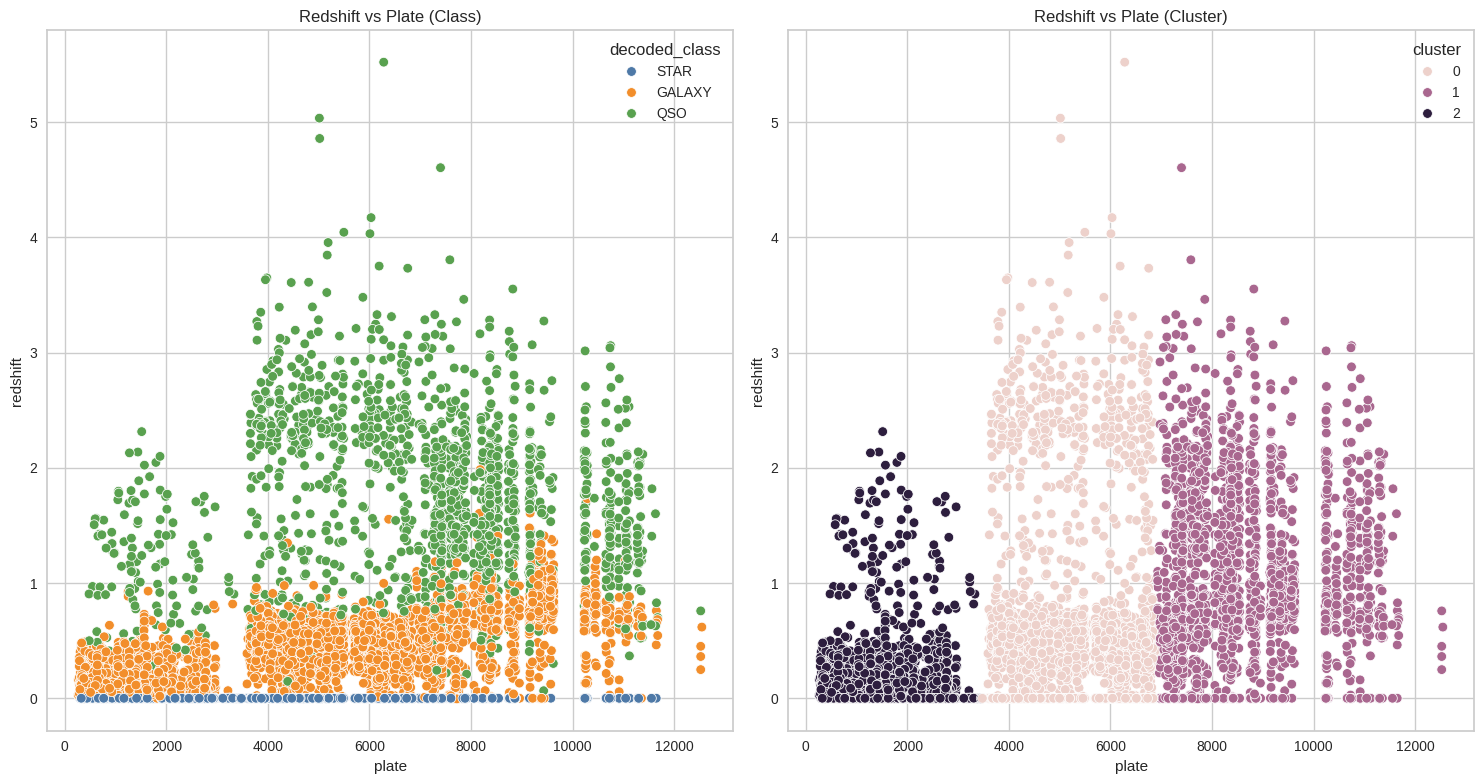

In [ ]:
class_mapping = {0: 'GALAXY', 1: 'QSO', 2: 'STAR'}
cleaned_stellar_df['decoded_class'] = cleaned_stellar_df['class'].map(class_mapping)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(cleaned_stellar_df[selected_features])
cleaned_stellar_df['cluster'] = kmeans_labels

# Decode original class for visualization
# cleaned_stellar_df['decoded_class'] = le.inverse_transform(cleaned_stellar_df['original_class'])

# Visualization: Redshift vs Plate (Decoded Class and Cluster)
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].set_title('Redshift vs Plate (Class)')
sns.scatterplot(data=cleaned_stellar_df, x='plate', y='redshift', hue='decoded_class', ax=axes[0])

axes[1].set_title('Redshift vs Plate (Cluster)')
sns.scatterplot(data=cleaned_stellar_df, x='plate', y='redshift', hue='cluster', ax=axes[1])
plt.tight_layout()
plt.show()



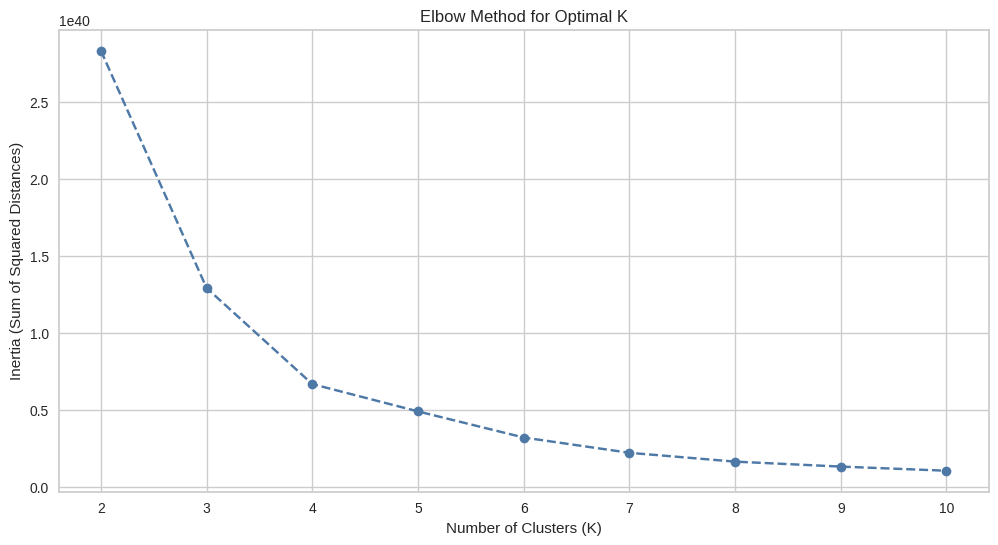

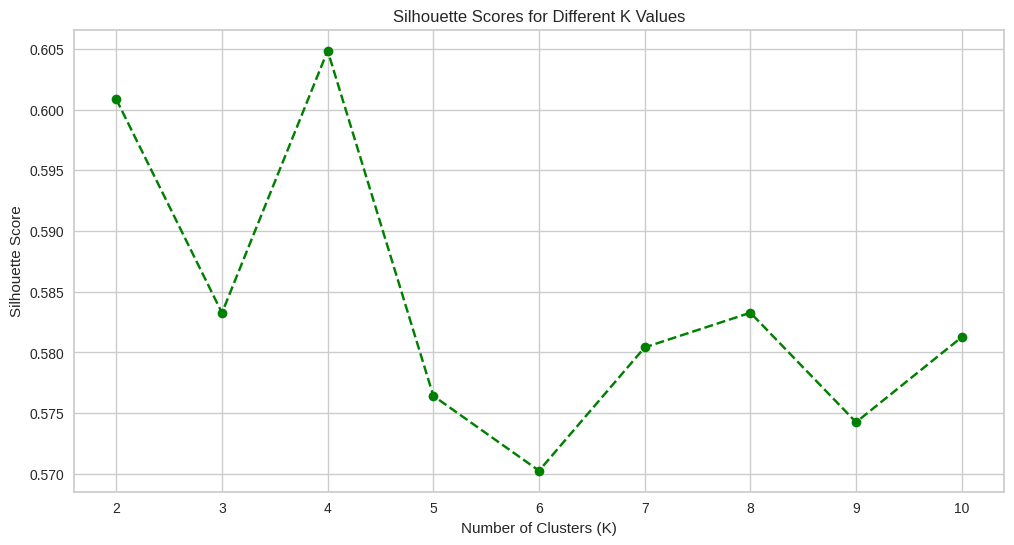

4

In [ ]:
# Elbow Method
inertia = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(12, 6))
plt.plot(range(2, 11), inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(12, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--', color='green')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different K Values')
plt.grid(True)
plt.show()

# Return optimal K based on both methods
optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2  # Adjust for range starting at 2
optimal_k


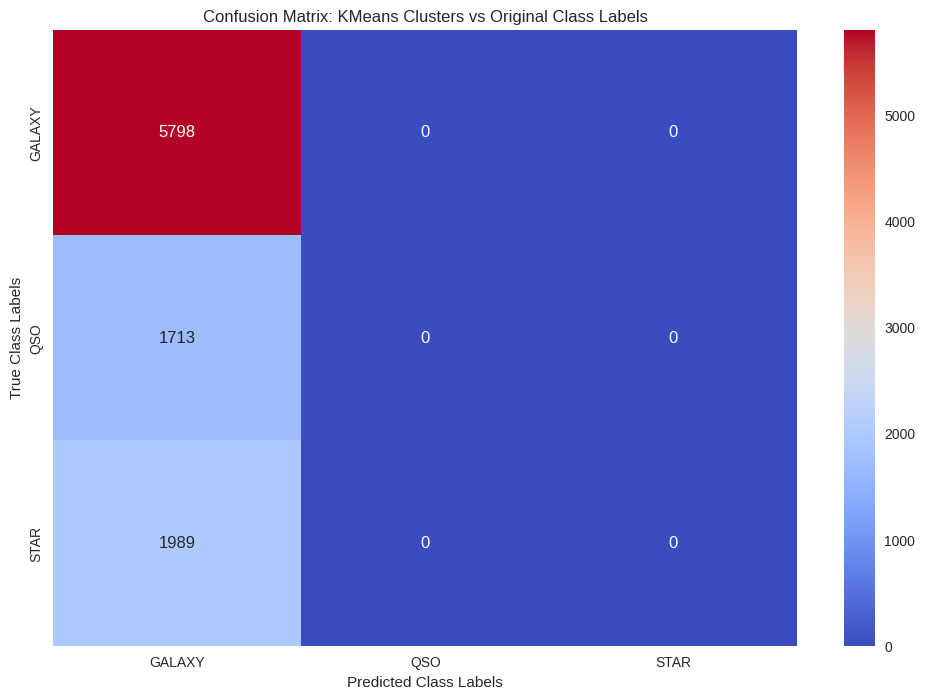

Silhouette Score: 0.5832615509969509
Accuracy: 0.6103157894736843
Classification Report:               precision    recall  f1-score   support

      GALAXY       0.61      1.00      0.76      5798
      QUASAR       0.00      0.00      0.00      1713
        STAR       0.00      0.00      0.00      1989

    accuracy                           0.61      9500
   macro avg       0.20      0.33      0.25      9500
weighted avg       0.37      0.61      0.46      9500

Confusion Matrix: [[5798, 0, 0], [1713, 0, 0], [1989, 0, 0]]


In [ ]:
# Convert X_smote to DataFrame for compatibility
X_df = pd.DataFrame(X, columns=selected_features)
y_df = pd.Series(y)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Calculate silhouette score
silhouette = silhouette_score(X, kmeans_labels)

# Map clusters to actual class labels using value_counts()
cluster_to_class = {}
for cluster in range(3):
    labels = y_df[kmeans_labels == cluster]
    most_common_label = labels.value_counts().idxmax()
    cluster_to_class[cluster] = most_common_label

# Create cluster columns in the DataFrame
X_df['cluster'] = kmeans_labels
X_df['original_class'] = y_df.values
X_df['mapped_cluster'] = X_df['cluster'].map(cluster_to_class)

# Calculate accuracy
accuracy = accuracy_score(y_df, X_df['mapped_cluster'])

# Confusion Matrix
conf_matrix = confusion_matrix(y_df, X_df['mapped_cluster'])

# Generate Classification Report
# Generate Classification Report
class_labels = ['GALAXY', 'QUASAR', 'STAR']  # Define the target names explicitly
class_report = classification_report(
    y_df,
    X_df['mapped_cluster'],
    target_names=class_labels
)


# Display results
results = {
    "Silhouette Score": silhouette,
    "Accuracy": accuracy,
    "Classification Report": class_report,
    "Confusion Matrix": conf_matrix.tolist()
}

# Plot the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm', xticklabels=LE.classes_, yticklabels=LE.classes_)
plt.title("Confusion Matrix: KMeans Clusters vs Original Class Labels")
plt.xlabel("Predicted Class Labels")
plt.ylabel("True Class Labels")
plt.show()

# Print the results
for key, value in results.items():
    print(f"{key}: {value}")


##OVERSAMPLING: I will apply SMOTE to the imbalanced Stellar Classification Dataset and Test the Models agaian.

In [ ]:
y.value_counts()

,count
class,
0,5798
2,1989
1,1713


##Handling The Imbalanced Dataset

In [ ]:
sm = SMOTE(random_state=42)
X_smote, y_smote = sm.fit_resample(X, y)

In [ ]:
# # Split the new DataFrame into features and target
# X_smote_final = smote_df.drop('class', axis=1)
# y_smote_final = smote_df['class']

In [ ]:
y_smote.value_counts()

,count
class,
2,5798
0,5798
1,5798


Class Distribution Before SMOTE:
class
0    5798
2    1989
1    1713
Name: count, dtype: int64

Class Distribution After SMOTE:
class
2    5798
0    5798
1    5798
Name: count, dtype: int64


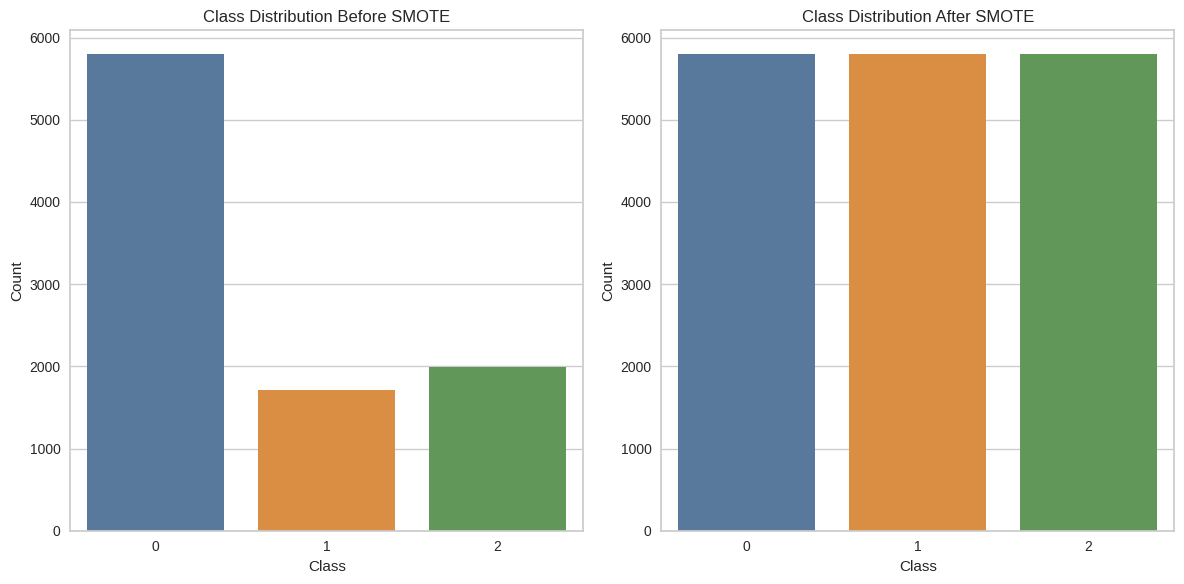

In [ ]:
# --- Class Distribution Before SMOTE ---
print("Class Distribution Before SMOTE:")
print(y.value_counts())

# Plot the class distribution before SMOTE
class_counts_before = y.value_counts().to_frame(name='Count')
class_counts_before['Percentage'] = (class_counts_before['Count'] / y.shape[0] * 100).round(2)

palette = ['#4e79a7', '#f28e2b', '#59a14f']
plt.figure(figsize=(12, 6))
plt.subplot(121)
sns.barplot(x=class_counts_before.index, y='Count', data=class_counts_before, palette=palette)
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')

# --- Apply SMOTE ---
sm = SMOTE(random_state=42)
X_smote, y_smote = sm.fit_resample(X, y)

# --- Class Distribution After SMOTE ---
print("\nClass Distribution After SMOTE:")
print(y_smote.value_counts())

# Plot the class distribution after SMOTE
class_counts_after = y_smote.value_counts().to_frame(name='Count')
class_counts_after['Percentage'] = (class_counts_after['Count'] / y_smote.shape[0] * 100).round(2)

plt.subplot(122)
sns.barplot(x=class_counts_after.index, y='Count', data=class_counts_after, palette=palette)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')

# Show plots
plt.tight_layout()
plt.show()


##**Random Forest Classifier After applying SMOTE**

In [ ]:
X_smote_train, X_smote_test, y_smote_train, y_smote_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=747)

In [ ]:
r_forest = RandomForestClassifier(random_state=747)
r_forest.fit(X_smote_train,y_smote_train)
predicted = r_forest.predict(X_smote_test)
decoded_predictions = LE.inverse_transform(predicted)
score = r_forest.score(X_smote_test, y_smote_test)
rf_score_ = np.mean(score)

print('Accuracy : %.5f' % (rf_score_))

Accuracy : 0.98620


Confusion Matrix

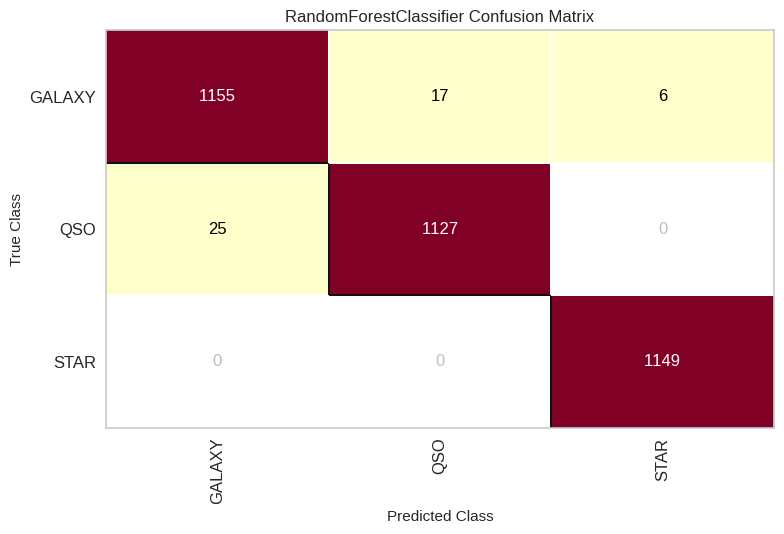

<Axes: title={'center': 'RandomForestClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
r_forest_cm = ConfusionMatrix(r_forest, classes=LE.classes_)

r_forest_cm.fit(X_smote_train, y_smote_train)
r_forest_cm.score(X_smote_test, y_smote_test)
r_forest_cm.show()

Classification Report

In [ ]:
y_test_decoded = LE.inverse_transform(y_smote_test)
predicted_decoded = LE.inverse_transform(predicted)

# Generate the classification report
report = classification_report(y_test_decoded, predicted_decoded)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98      1178
         QSO       0.99      0.98      0.98      1152
        STAR       0.99      1.00      1.00      1149

    accuracy                           0.99      3479
   macro avg       0.99      0.99      0.99      3479
weighted avg       0.99      0.99      0.99      3479



ROC Curve

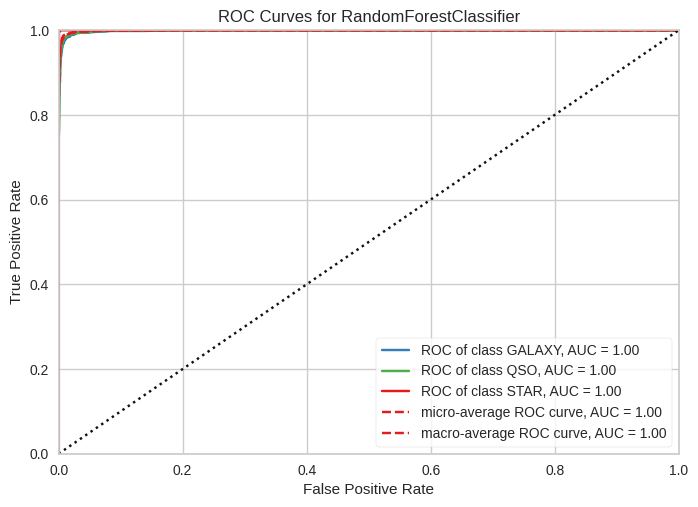

<Axes: title={'center': 'ROC Curves for RandomForestClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
visualizer = ROCAUC(r_forest, classes=LE.classes_)

set_palette('bold')

visualizer.fit(X_smote_train, y_smote_train)
visualizer.score(X_smote_test, y_smote_test)
visualizer.show()

Class Prediction Error

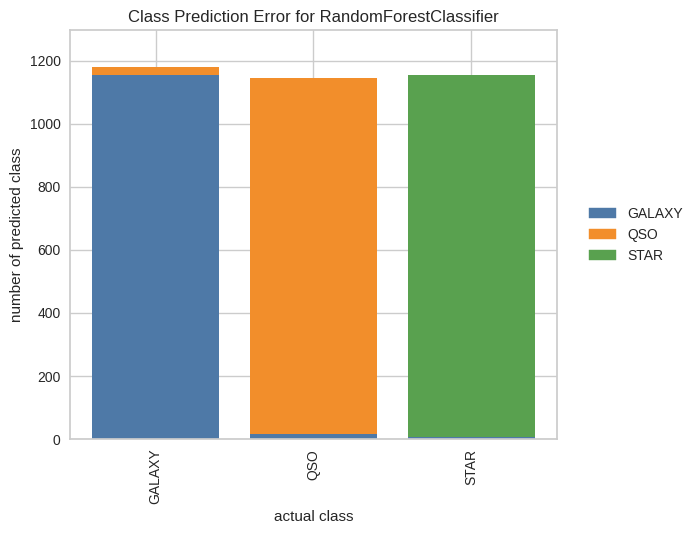

<Axes: title={'center': 'Class Prediction Error for RandomForestClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [ ]:
visualizer = ClassPredictionError(r_forest, classes=LE.classes_)
palette = ['#4e79a7', '#f28e2b', '#59a14f']

set_palette(palette)

visualizer.fit(X_smote_train, y_train)
visualizer.score(X_smote_test, y_smote_test)
visualizer.show()

##**Extra Trees Classifier After applying SMOTE**

In [ ]:
# Initialize and train the ExtraTreesClassifier
et_classifier = ExtraTreesClassifier(random_state=747)
et_classifier.fit(X_smote_train, y_smote_train)

# Make predictions and decode them back to original class names
et_predicted = et_classifier.predict(X_smote_test)
et_decoded_predictions = LE.inverse_transform(et_predicted)

# Calculate accuracy
et_score = et_classifier.score(X_smote_test, y_smote_test)
et_accuracy = np.mean(et_score)
print('Accuracy: %.5f' % (et_accuracy))

Accuracy: 0.98649


Confusion Matrix

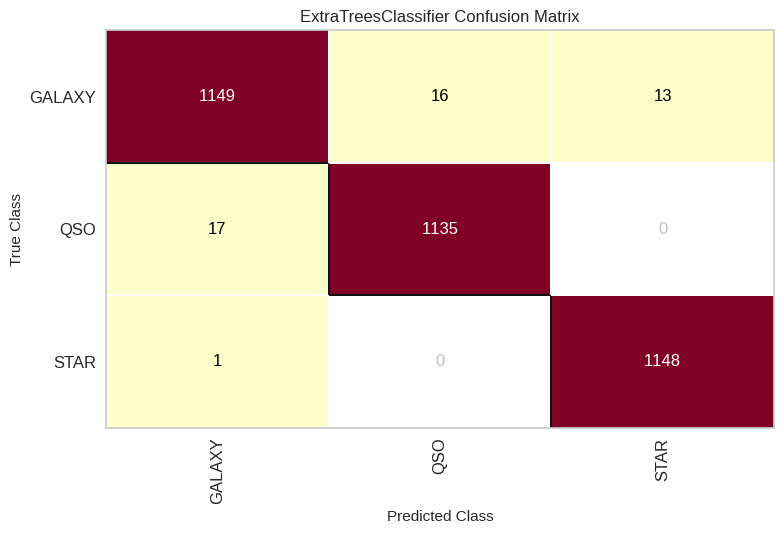

<Axes: title={'center': 'ExtraTreesClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
# Generate the Confusion Matrix
et_cm = ConfusionMatrix(et_classifier, classes=LE.classes_)
et_cm.fit(X_smote_train, y_smote_train)
et_cm.score(X_smote_test, y_smote_test)
et_cm.show()

ROC Curve

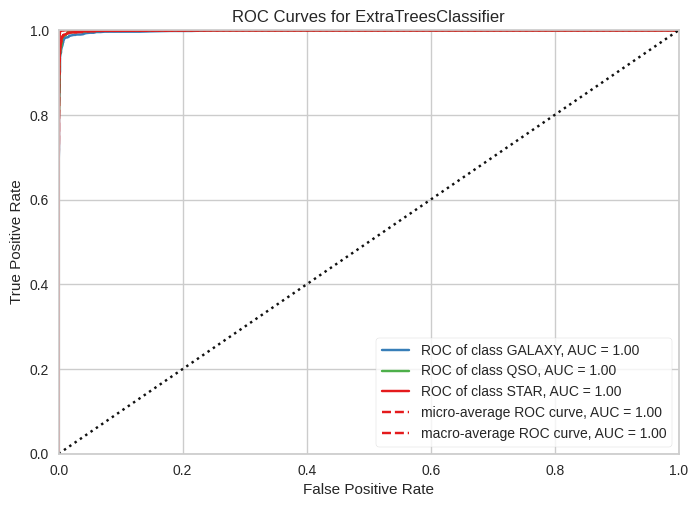

<Axes: title={'center': 'ROC Curves for ExtraTreesClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
# Plot the ROC Curve
et_roc = ROCAUC(et_classifier, classes=LE.classes_)
set_palette('bold')

et_roc.fit(X_smote_train, y_smote_train)
et_roc.score(X_smote_test, y_smote_test)
et_roc.show()

Class Prediction Error

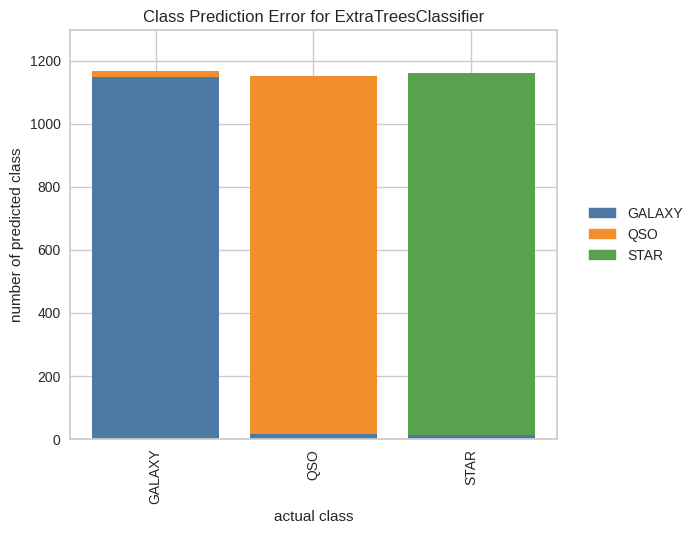

<Axes: title={'center': 'Class Prediction Error for ExtraTreesClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [ ]:
# Generate the Class Prediction Error plot
et_cpe = ClassPredictionError(et_classifier, classes=LE.classes_)
palette = ['#4e79a7', '#f28e2b', '#59a14f']
set_palette(palette)

et_cpe.fit(X_smote_train, y_smote_train)
et_cpe.score(X_smote_test, y_smote_test)
et_cpe.show()

##**KMeans Clustering After applying SMOTE**

In [ ]:
# Convert X_smote to a DataFrame (using the same feature names as the original X)
X_smote_df = pd.DataFrame(X_smote, columns=X.columns)

# Convert y_smote to a DataFrame and rename the column to 'class' (or your target label name)
y_smote_df = pd.DataFrame(y_smote, columns=['class'])

# Combine the features and target into a single DataFrame
smote_df = pd.concat([X_smote_df, y_smote_df], axis=1)

# Check the new DataFrame
print(smote_df.head())
print("Shape of the new DataFrame:", smote_df.shape)

          u         g         r         i         z   spec_obj_ID  redshift  \
0  19.44393  18.43291  18.11620  17.98857  17.95942  3.587172e+18 -0.000996   
1  22.41654  22.09867  20.53718  19.63900  19.28375  7.513333e+18  0.518672   
2  19.49719  17.58264  16.66178  16.18781  15.85648  4.608454e+18  0.077720   
3  24.31149  21.99310  20.58364  19.76995  19.39575  4.445071e+18  0.471659   
4  25.61850  24.86680  21.37659  19.77067  19.26844  5.199500e+18  0.720088   

   plate    MJD  class  
0   3186  54853      2  
1   6673  56419      0  
2   4093  55475      0  
3   3948  55331      0  
4   4618  55600      0  
Shape of the new DataFrame: (17394, 10)


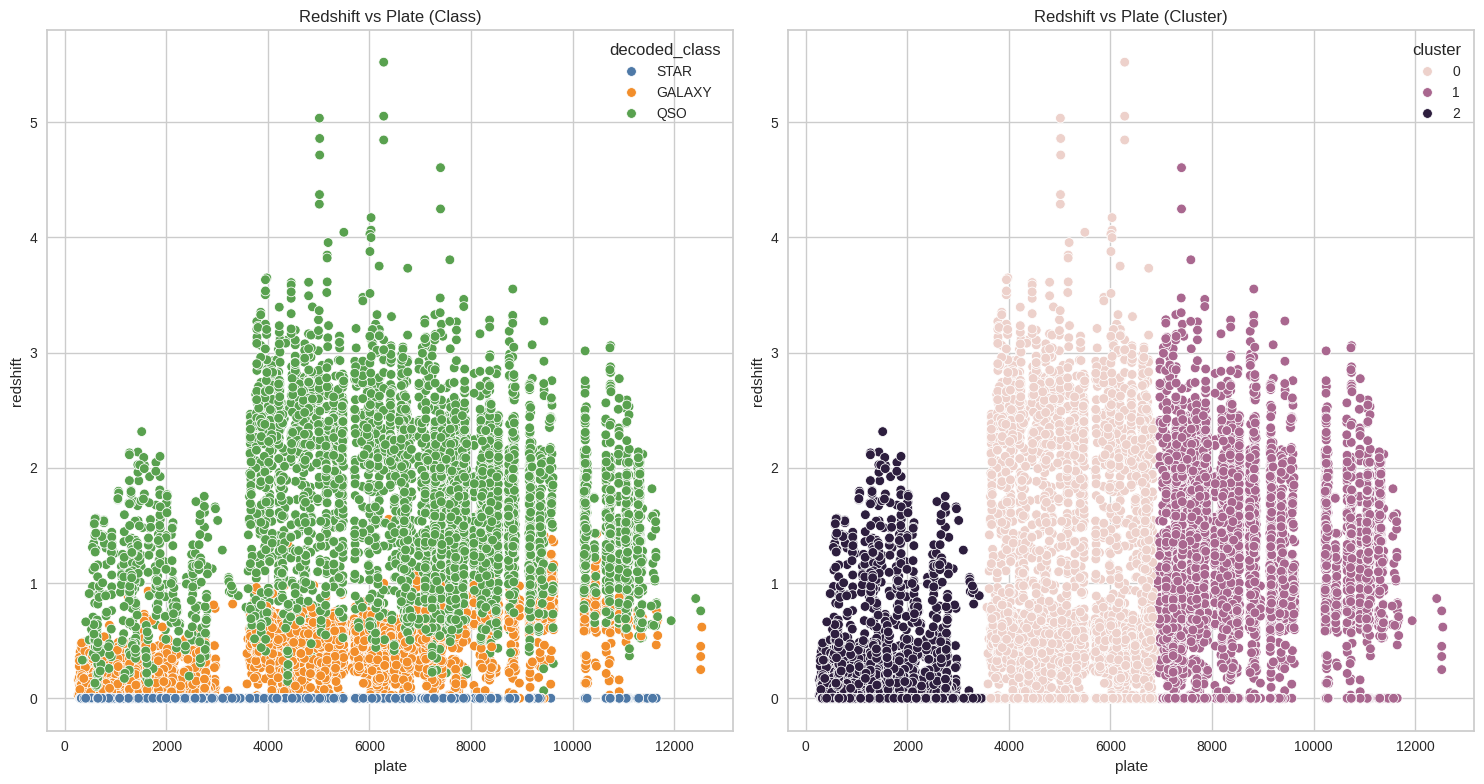

In [ ]:

class_mapping = {0: 'GALAXY', 1: 'QSO', 2: 'STAR'}
smote_df['decoded_class'] = smote_df['class'].map(class_mapping)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(smote_df[selected_features])
smote_df['cluster'] = kmeans_labels

# Visualization: Redshift vs Plate (Decoded Class and Cluster)
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].set_title('Redshift vs Plate (Class)')
sns.scatterplot(data=smote_df, x='plate', y='redshift', hue='decoded_class', ax=axes[0])

axes[1].set_title('Redshift vs Plate (Cluster)')
sns.scatterplot(data=smote_df, x='plate', y='redshift', hue='cluster', ax=axes[1])
plt.tight_layout()
plt.show()



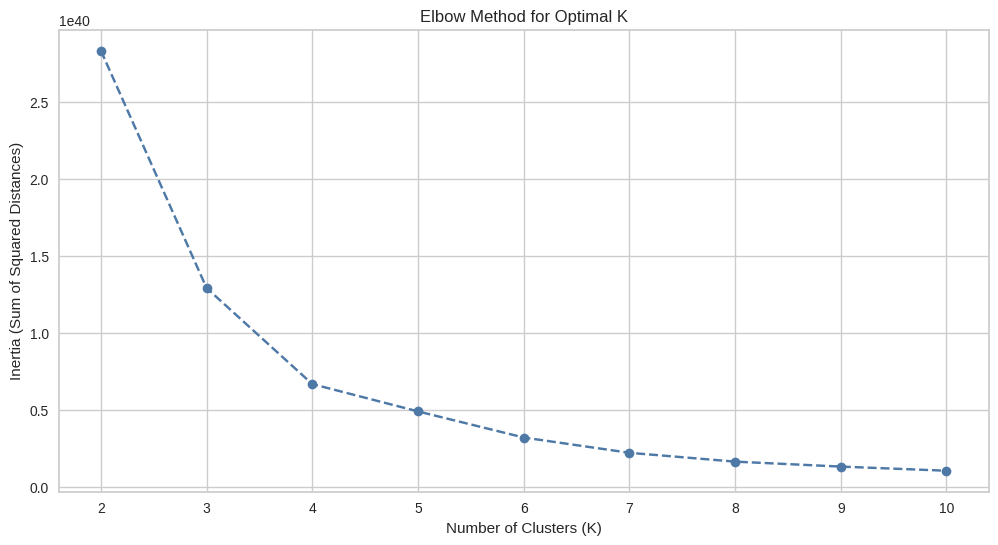

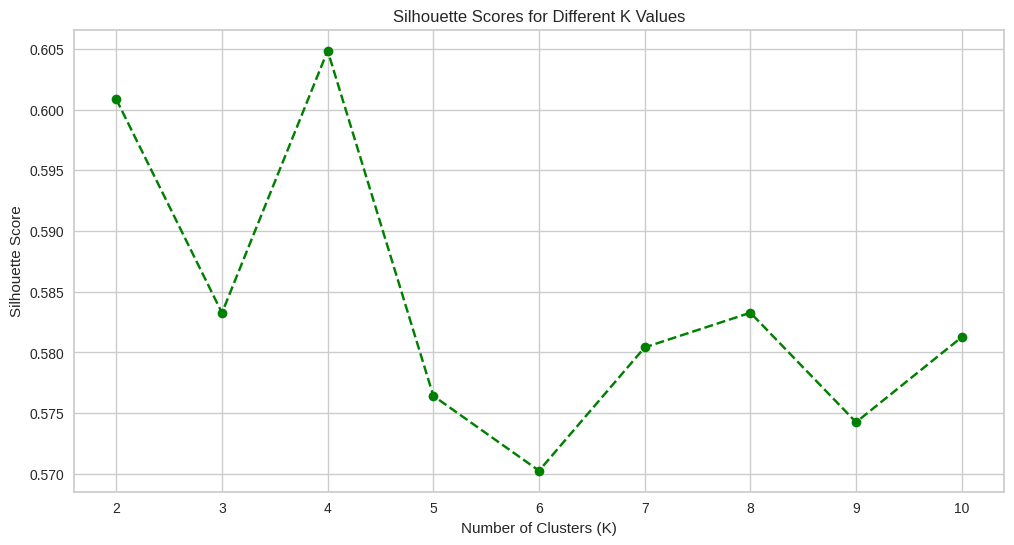

4

In [ ]:
# Elbow Method
inertia = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(12, 6))
plt.plot(range(2, 11), inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(12, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--', color='green')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different K Values')
plt.grid(True)
plt.show()

# Return optimal K based on both methods
optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2  # Adjust for range starting at 2
optimal_k


In [ ]:
X_smote.shape

(17394, 9)

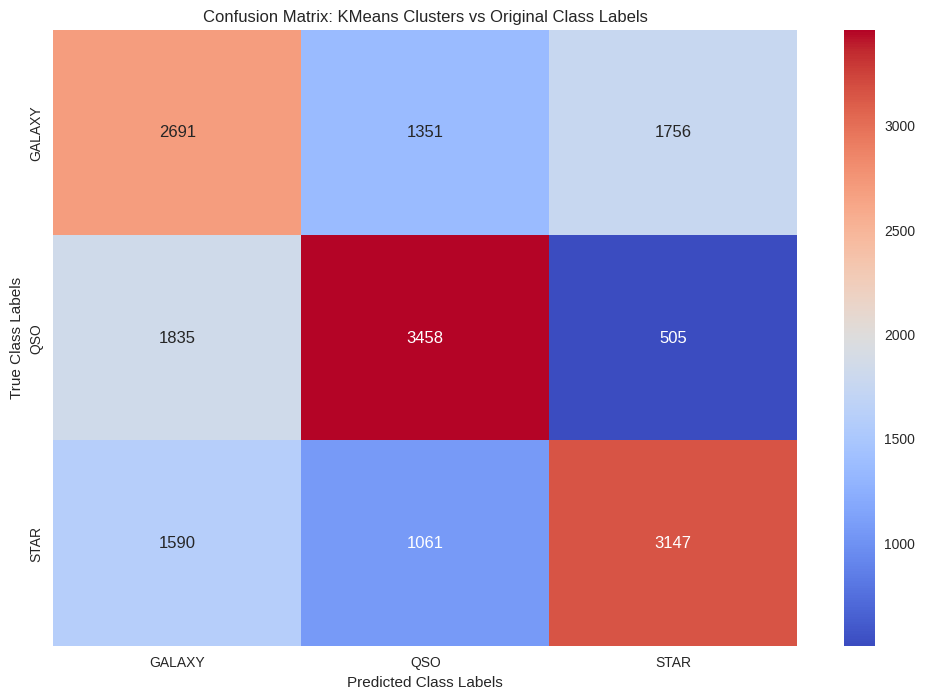

Silhouette Score: 0.5702194096384275
Accuracy: 0.5344371622398528
Classification Report:               precision    recall  f1-score   support

      GALAXY       0.44      0.46      0.45      5798
      QUASAR       0.59      0.60      0.59      5798
        STAR       0.58      0.54      0.56      5798

    accuracy                           0.53     17394
   macro avg       0.54      0.53      0.54     17394
weighted avg       0.54      0.53      0.54     17394

Confusion Matrix: [[2691, 1351, 1756], [1835, 3458, 505], [1590, 1061, 3147]]


In [ ]:
# Convert X_smote to DataFrame for compatibility
X_smote_df = pd.DataFrame(X_smote, columns=selected_features)
y_smote_df = pd.Series(y_smote)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_smote)

# Calculate silhouette score
silhouette = silhouette_score(X_smote, kmeans_labels)

# Map clusters to actual class labels using value_counts()
cluster_to_class = {}
for cluster in range(3):
    labels = y_smote_df[kmeans_labels == cluster]
    most_common_label = labels.value_counts().idxmax()
    cluster_to_class[cluster] = most_common_label

# Create cluster columns in the DataFrame
X_smote_df['cluster'] = kmeans_labels
X_smote_df['original_class'] = y_smote_df.values
X_smote_df['mapped_cluster'] = X_smote_df['cluster'].map(cluster_to_class)

# Calculate accuracy
accuracy = accuracy_score(y_smote_df, X_smote_df['mapped_cluster'])

# Confusion Matrix
conf_matrix = confusion_matrix(y_smote_df, X_smote_df['mapped_cluster'])

# Classification Report
# class_report = classification_report(y_smote_df, X_smote_df['mapped_cluster'], target_names=le.classes_)

# Generate Classification Report
# Generate Classification Report
class_labels = ['GALAXY', 'QUASAR', 'STAR']  # Define the target names explicitly
class_report = classification_report(
    y_smote_df,
    X_smote_df['mapped_cluster'],
    target_names=class_labels
)


# Display results
results = {
    "Silhouette Score": silhouette,
    "Accuracy": accuracy,
    "Classification Report": class_report,
    "Confusion Matrix": conf_matrix.tolist()
}

# Plot the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm', xticklabels=LE.classes_, yticklabels=LE.classes_)
plt.title("Confusion Matrix: KMeans Clusters vs Original Class Labels")
plt.xlabel("Predicted Class Labels")
plt.ylabel("True Class Labels")
plt.show()

# Print the results
for key, value in results.items():
    print(f"{key}: {value}")


##HYPERPARAMETER TUNING ON RANDOM FOREST CLASSIFIER

In [ ]:
# Define the pipeline with a named step
pipeline = Pipeline([
    ('random_forest', RandomForestClassifier(random_state=42))
])

# Define the hyperparameter grid using the correct step name
param_grid = {
    'random_forest__n_estimators': [50, 100, 200],
    'random_forest__max_depth': [None, 10, 20],
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_smote_train, y_smote_train)

# Output the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Parameters: {'random_forest__max_depth': None, 'random_forest__n_estimators': 50}


In [ ]:
model = RandomForestClassifier(n_estimators=200, max_depth=None)
model.fit(X_smote_train, y_smote_train)

RandomForestClassifier(n_estimators=200)

In [ ]:
predictions = model.predict(X_smote_test)
print(classification_report(y_smote_test, predictions, digits=5))

              precision    recall  f1-score   support

           0    0.97961   0.97878   0.97919      1178
           1    0.98429   0.97917   0.98172      1152
           2    0.99394   1.00000   0.99696      1149

    accuracy                        0.98592      3479
   macro avg    0.98595   0.98598   0.98596      3479
weighted avg    0.98589   0.98592   0.98590      3479



##USING VOTING CLASSIFIER ENSEMBLE MODEL

In [ ]:
# Define individual classifiers
classifiers = [
    ('Random Forest', RandomForestClassifier(random_state=747)),
    ('Extra Trees', ExtraTreesClassifier(random_state=747)),
]

# ---- Create a VotingClassifier with Hard Voting ----
voting_clf_hard = VotingClassifier(estimators=classifiers, voting='hard')

# ---- Create a VotingClassifier with Soft Voting ----
voting_clf_soft = VotingClassifier(estimators=classifiers, voting='soft')

# ---- Evaluate Hard Voting Classifier with Cross-Validation ----
scores_hard = cross_val_score(voting_clf_hard, X_smote, y_smote, cv=5)
print(f"Hard Voting Cross-Validation Accuracy: {scores_hard.mean():.4f} ± {scores_hard.std():.4f}")

# ---- Evaluate Soft Voting Classifier with Cross-Validation ----
scores_soft = cross_val_score(voting_clf_soft, X_smote, y_smote, cv=5)
print(f"Soft Voting Cross-Validation Accuracy: {scores_soft.mean():.4f} ± {scores_soft.std():.4f}")


Hard Voting Cross-Validation Accuracy: 0.9833 ± 0.0031
Soft Voting Cross-Validation Accuracy: 0.9842 ± 0.0030
